# Dự đoán số lượt thuê xe theo giờ

## 1. Project Overview

### 1.1. Data Scope

Project này tập trung vào việc **phân tích và dự đoán số lượng xe đạp được thuê theo từng giờ** dựa trên các yếu tố về thời gian, thời tiết và đặc điểm của ngày.

Dataset được sử dụng là **Bike Sharing Dataset** từ UCI Machine Learning Repository, được thu thập từ hệ thống Capital Bikeshare trong giai đoạn **2011–2012**. Dataset cung cấp dữ liệu thuê xe theo giờ cùng với các thông tin về mùa, thời gian, ngày lễ và điều kiện thời tiết.

Dataset có **17,389 bản ghi và 13 features**, không chứa missing values.

**Nguồn dữ liệu:** [UCI Machine Learning Repository – Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

---

### 1.2. Problem Statement

Nhu cầu sử dụng xe đạp chia sẻ thay đổi theo **thời gian trong ngày, ngày trong tuần, mùa và điều kiện thời tiết**. Việc dự đoán chính xác nhu cầu thuê xe có thể hỗ trợ việc phân bổ và quản lý số lượng xe hiệu quả hơn.

Trong project này, bài toán được xây dựng dưới dạng **Supervised Learning – Regression**, với mục tiêu dự đoán tổng số lượt thuê xe trong một giờ.

**Target variable:**

* `cnt`: tổng số lượt thuê xe trong một giờ, bao gồm cả người dùng casual và registered.

**Input features** bao gồm:

* Thông tin thời gian: `yr`, `mnth`, `hr`, `weekday`
* Thông tin ngày: `holiday`, `workingday`
* Mùa và thời tiết: `season`, `weathersit`
* Điều kiện môi trường: `temp`, `atemp`, `hum`, `windspeed`

Các định nghĩa và cách mã hóa biến được lấy từ tài liệu chính thức của UCI.

---

### 1.3. Project Objectives

Project hướng đến các mục tiêu chính:

1. **Khám phá dữ liệu (EDA)** để tìm hiểu xu hướng thuê xe theo thời gian và điều kiện thời tiết.
2. Phân tích mối quan hệ giữa các features và số lượt thuê xe.
3. Tiền xử lý và xây dựng tập dữ liệu phù hợp cho Machine Learning.
4. Xây dựng các mô hình **Regression** để dự đoán `cnt`.
5. Đánh giá và so sánh hiệu năng giữa các mô hình.
6. Xác định những yếu tố có ảnh hưởng đáng kể đến nhu cầu thuê xe.

---

### 1.4. Project Workflow

Project được triển khai theo quy trình:

**Data Collection → Data Understanding → Exploratory Data Analysis → Data Preprocessing → Feature Engineering → Model Training → Model Evaluation → Model Interpretation**

Trong đó:

* **Data Understanding:** kiểm tra cấu trúc, kiểu dữ liệu và chất lượng dữ liệu.
* **EDA:** phân tích xu hướng số lượt thuê xe theo giờ, ngày, mùa và thời tiết.
* **Preprocessing:** xử lý categorical features và chuẩn bị dữ liệu cho mô hình.
* **Feature Engineering:** tạo thêm các đặc trưng thời gian nếu cần thiết.
* **Modeling:** xây dựng và so sánh các mô hình Regression.
* **Evaluation:** sử dụng các metrics như **MAE, RMSE và R²** để đánh giá mô hình.

---

### 1.5. Expected Outcome

Sau khi hoàn thành project, mô hình có khả năng dự đoán số lượt thuê xe theo giờ dựa trên các thông tin về thời gian và điều kiện môi trường.

Ngoài khả năng dự đoán, project cũng hướng đến việc trả lời các câu hỏi như:

* Khung giờ nào có nhu cầu thuê xe cao nhất?
* Nhu cầu thuê xe thay đổi như thế nào giữa các mùa?
* Thời tiết có ảnh hưởng đến số lượt thuê xe không?
* Ngày làm việc và ngày nghỉ có tạo ra sự khác biệt về nhu cầu không?
* Những yếu tố nào có ảnh hưởng lớn nhất đến số lượt thuê xe?


## 2. Import Libraries

In [328]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

# Các import của bạn giữ nguyên bên dưới
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dcor
import math
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.compose import ColumnTransformer
import copy
from sklearn.base import clone

## 3. Data Loading

In [329]:
df = pd.read_csv("./datas/hour.csv")

## 4. Data Understanding

In [330]:
df.shape

(17379, 17)

In [331]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [332]:
df.tail(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [333]:
df.head(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


1. Giải thích các cột:
    - **`instant`**: Mã định danh / Số thứ tự dòng
    - **`dteday`**: Ngày ghi nhận dữ liệu (`YYYY-MM-DD`)
    - **`season`**: Mùa trong năm (`1`: Mùa xuân, `2`: Mùa hạ, `3`: Mùa thu, `4`: Mùa đông)
    - **`yr`**: Năm (`0`: 2011, `1`: 2012)
    - **`mnth`**: Tháng trong năm (`1` đến `12`)
    - **`hr`**: Giờ trong ngày (`0` đến `23`, chỉ có trong `hour.csv`)
    - **`holiday`**: Có phải ngày lễ không (`1`: Có, `0`: Không)
    - **`weekday`**: Ngày trong tuần (`0` đến `6`)
    - **`workingday`**: Có phải ngày làm việc không (`1`: Không phải cuối tuần hay ngày lễ, `0`: Khác)
    - **`weathersit`**: Tình trạng thời tiết (`1`: Đẹp/Trong xanh $\rightarrow$ `4`: Thời tiết xấu/Mưa tuyết nặng)
    - **`temp`**: Nhiệt độ môi trường (đã chuẩn hóa, chia cho max 41°C)
    - **`atemp`**: Nhiệt độ cảm nhận (đã chuẩn hóa, chia cho max 50°C)
    - **`hum`**: Độ ẩm không khí (đã chuẩn hóa, chia cho max 100)
    - **`windspeed`**: Tốc độ gió (đã chuẩn hóa, chia cho max 67)
    - **`casual`**: Số lượng xe được thuê bởi khách vãng lai
    - **`registered`**: Số lượng xe được thuê bởi thành viên đã đăng ký
    - **`cnt`**: Tổng số xe được thuê (`cnt = casual + registered`)
2. Hình dạng của data:
    - Bao gồm có 17379 hàng và 17 cột

In [334]:
# Ép kiểu dữ liệu str thành datetime cho column dteday
df['dteday'] = pd.to_datetime(df['dteday'])

In [335]:
# Ép kiểu dữ liệu int thành category
cat_cols = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit',
]

# Chuyển đồng loạt sang category (chỉ áp dụng các cột thực tế có trong dataframe)
cols_to_convert = [col for col in cat_cols if col in df.columns]
df[cols_to_convert] = df[cols_to_convert].astype('category')

In [336]:
df.describe()

,instant,dteday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [337]:
def check_null(df):
    print("=" * 60)
    print("2. KIỂM TRA VALUE THIẾU (NULL / MISSING VALUES)")
    print("=" * 60)
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100

    null_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage (%)': null_pct.round(2),
        'Data Type': df.dtypes
    })

    # Chỉ hiển thị các cột có chứa Null (hoặc báo nếu sạch null)
    cols_with_null = null_df[null_df['Null Count'] > 0]
    if len(cols_with_null) == 0:
        print("=> Tuyệt vời! Không có cột nào bị thiếu dữ liệu (No Nulls).\n")
    else:
        print(cols_with_null)

check_null(df)

2. KIỂM TRA VALUE THIẾU (NULL / MISSING VALUES)
=> Tuyệt vời! Không có cột nào bị thiếu dữ liệu (No Nulls).



In [338]:
target_cols = ['casual','registered']
numerical_cols = [num_cols for num_cols in df.select_dtypes(include=[np.number]).columns.tolist() if num_cols not in target_cols]
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

In [339]:
def analyze_shape_metrics(
    df: pd.DataFrame, columns: list[str]
) -> pd.DataFrame:
    """Phân tích và đọc vị (interpret) Skewness và Kurtosis cho các cột số.

    Rule Skewness (Độ lệch):
      - |Skew| < 0.5   : Khá đối xứng (Symmetric)
      - 0.5 <= Skew < 1: Lệch vừa (Moderately Skewed)
      - Skew >= 1      : Lệch mạnh (Highly Skewed)
      - Skew > 0       : Lệch phải (Right-skewed / Tail dài bên phải)
      - Skew < 0       : Lệch trái (Left-skewed / Tail dài bên trái)

    Rule Kurtosis (Độ nhọn - Fisher's Kurtosis, Normal = 0):
      - Kurtosis > 0.5 : Đỉnh nhọn, đuôi dày (Leptokurtic - Nhô cao, nhiều Outliers)
      - Kurtosis < -0.5: Đỉnh bẹt, đuôi mỏng (Platykurtic - Tày/Bẹt)
      - Khác            : Đỉnh chuẩn (Mesokurtic - Gần phân phối chuẩn)
    """
    results = []

    for col in columns:
        series = df[col].dropna()
        if series.empty:
            continue

        skew = series.skew()
        kurt = series.kurtosis()  # Fisher's kurtosis (0 = Gaussian)

        # 1. Logic đọc vị Skewness
        if abs(skew) < 0.5:
            skew_type = "Khá đối xứng"
        elif skew >= 0.5:
            skew_type = f"Lệch phải ({'Mạnh' if skew >= 1 else 'Vừa'})"
        else:
            skew_type = f"Lệch trái ({'Mạnh' if skew <= -1 else 'Vừa'})"

        # 2. Logic đọc vị Kurtosis
        if kurt > 0.5:
            kurt_type = "Đỉnh nhọn / Đuôi dày"
        elif kurt < -0.5:
            kurt_type = "Đỉnh bẹt / Đuôi mỏng"
        else:
            kurt_type = "Đỉnh chuẩn"

        # 3. Gợi ý xử lý nhanh (Rule of thumb cho Data Prep)
        recommendation = "Bình thường"
        if skew >= 1:
            recommendation = "Nên Log-transform hoặc Box-Cox trước khi train"
        elif skew <= -1:
            recommendation = "Nên xử lý Outliers / Transform biến"

        results.append(
            {
                "feature": col,
                "skewness": round(skew, 3),
                "skewness_interpretation": skew_type,
                "kurtosis": round(kurt, 3),
                "kurtosis_interpretation": kurt_type,
                "recommendation": recommendation,
            }
        )

    return pd.DataFrame(results).set_index("feature")

analyze_shape_metrics(df,numerical_cols)


,skewness,skewness_interpretation,kurtosis,kurtosis_interpretation,recommendation
feature,,,,,
instant,0.000,Khá đối xứng,-1.200,Đỉnh bẹt / Đuôi mỏng,Bình thường
temp,-0.006,Khá đối xứng,-0.942,Đỉnh bẹt / Đuôi mỏng,Bình thường
atemp,-0.090,Khá đối xứng,-0.845,Đỉnh bẹt / Đuôi mỏng,Bình thường
hum,-0.111,Khá đối xứng,-0.826,Đỉnh bẹt / Đuôi mỏng,Bình thường
windspeed,0.575,Lệch phải (Vừa),0.591,Đỉnh nhọn / Đuôi dày,Bình thường
cnt,1.277,Lệch phải (Mạnh),1.417,Đỉnh nhọn / Đuôi dày,Nên Log-transform hoặc Box-Cox trước khi train


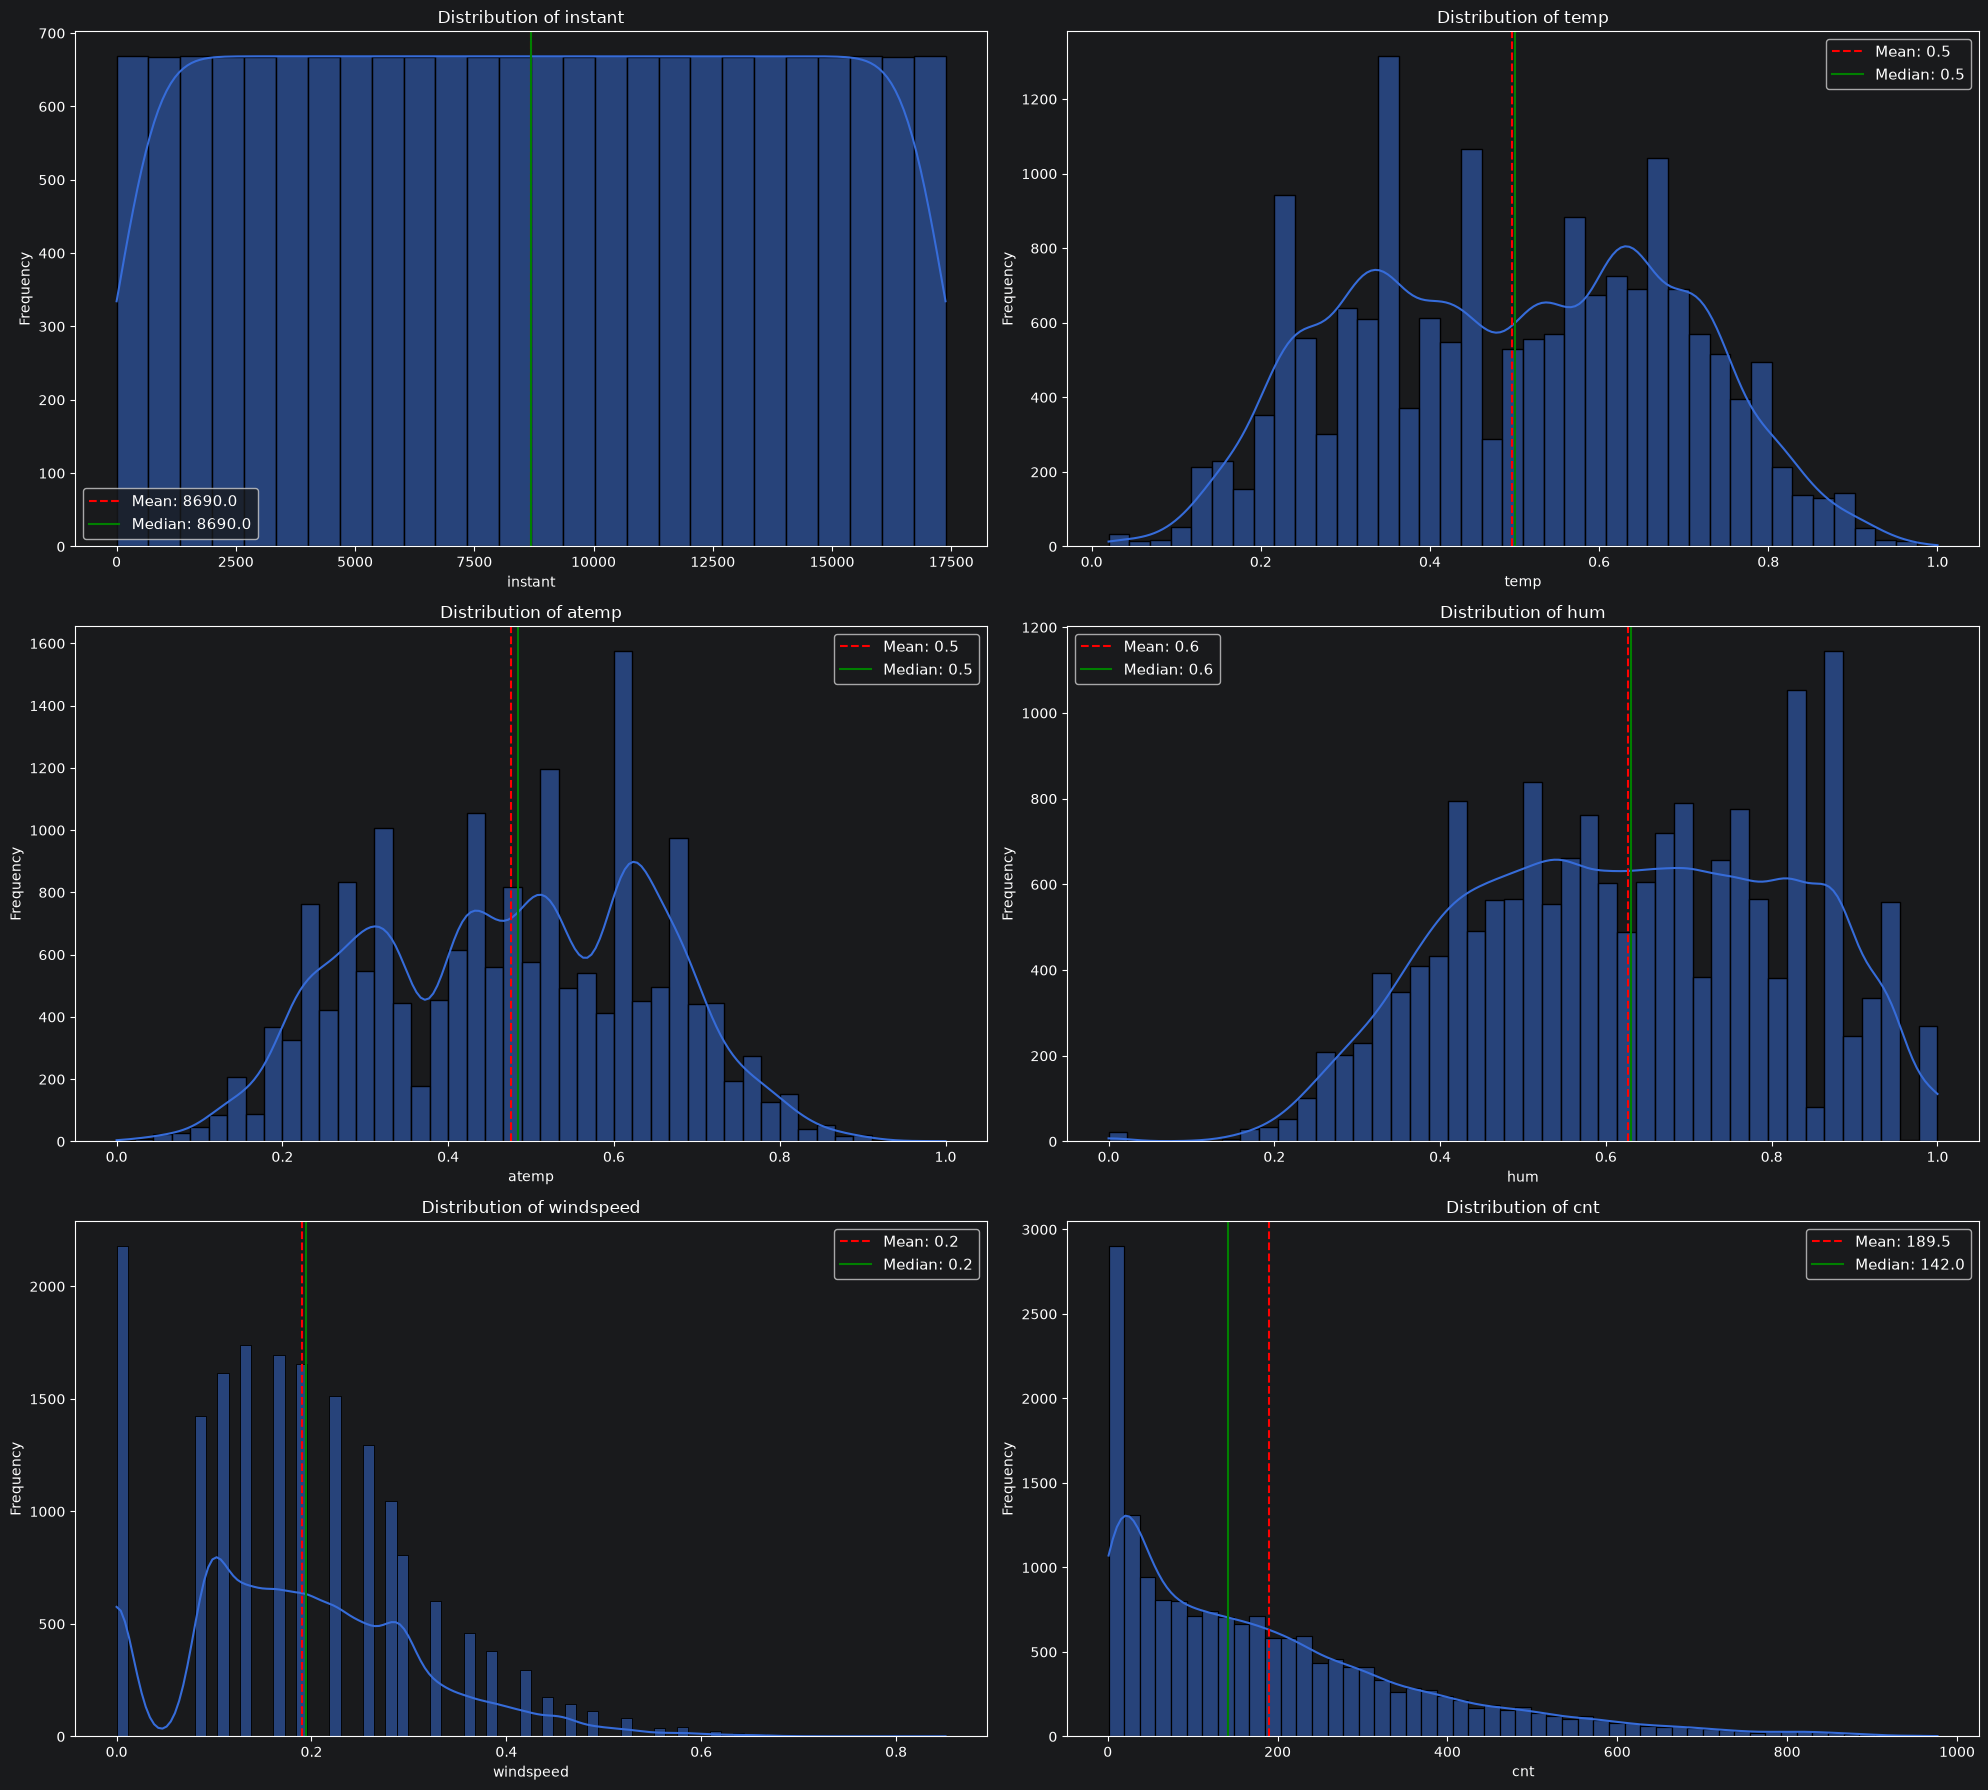

In [340]:
def plot_data_shape(df,num_cols):
    n_features = len(num_cols)
    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            ax=axes[i]
        )
        # Thêm đường thẳng thể hiện Mean và Median
        mean_val = df[col].mean()
        median_val = df[col].median()

        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
        axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')

        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
        axes[i].legend(fontsize=11)
    # Xóa subplot dư
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

plot_data_shape(df,numerical_cols)

In [341]:
def detect_outliers_report(df, features, iqr_factor=1.5, z_threshold=3.0):
    """Báo cáo so sánh Outliers giữa phương pháp IQR và Z-Score."""
    report = []
    total_rows = len(df)

    for col in features:
        # --- 1. Phương pháp IQR ---
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (iqr_factor * iqr)
        upper_bound = q3 + (iqr_factor * iqr)

        iqr_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        iqr_count = len(iqr_outliers)

        # --- 2. Phương pháp Z-Score ---
        # Tính z-score loại bỏ giá trị NaN nếu có
        z_scores = np.abs(stats.zscore(df[col].dropna()))
        z_count = (z_scores > z_threshold).sum()

        report.append(
            {
                "Feature": col,
                "IQR Outliers (Count)": iqr_count,
                "IQR Outliers (%)": round((iqr_count / total_rows) * 100, 2),
                "Z-Score Outliers (Count)": z_count,
                "Z-Score Outliers (%)": round((z_count / total_rows) * 100, 2),
            }
        )

    return pd.DataFrame(report)


# Chạy kiểm tra trên các features đã chọn
outlier_summary = detect_outliers_report(df, numerical_cols)
print(outlier_summary.to_string(index=False))

  Feature  IQR Outliers (Count)  IQR Outliers (%)  Z-Score Outliers (Count)  Z-Score Outliers (%)
  instant                     0              0.00                         0                  0.00
     temp                     0              0.00                         0                  0.00
    atemp                     0              0.00                         1                  0.01
      hum                    22              0.13                        22                  0.13
windspeed                   342              1.97                       107                  0.62
      cnt                   505              2.91                       244                  1.40


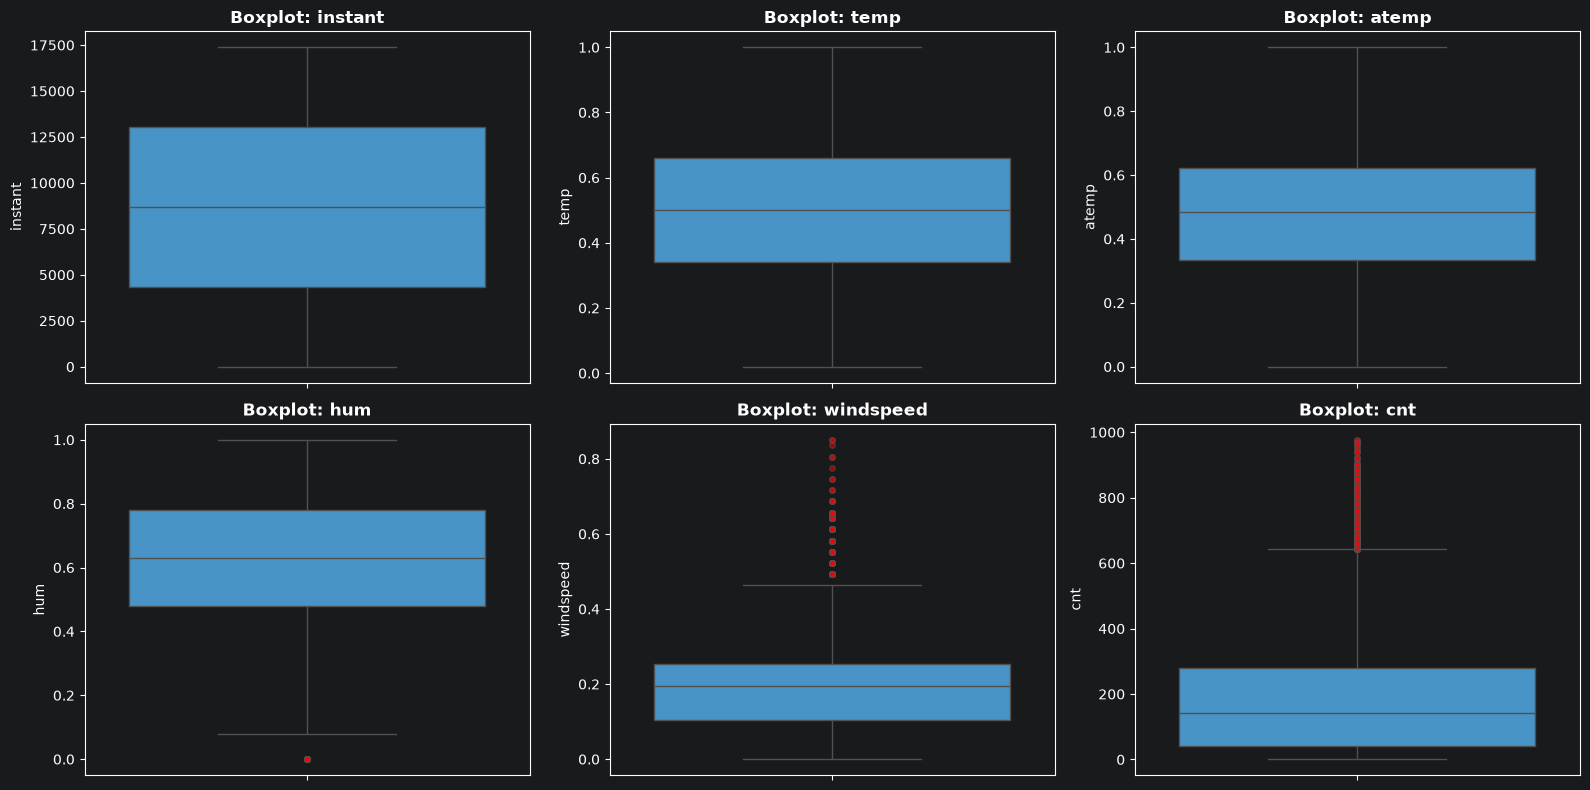

In [342]:
def plot_box_num(df,num_cols):
    # 2. Cấu hình lưới Subplots tự động
    n_features = len(num_cols)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    # 3. Vẽ Boxplot cho từng feature (sử dụng hue để tránh cảnh báo Seaborn >=0.14)
    for i, col in enumerate(num_cols):
        sns.boxplot(
            data=df,
            y=col,
            ax=axes[i],
            color="#3498db",
            flierprops={
                "marker": "o",
                "markerfacecolor": "red",
                "markersize": 4,
                "alpha": 0.5,
            },
        )
        axes[i].set_title(f"Boxplot: {col}", fontsize=12, fontweight="bold")
        axes[i].set_ylabel(col, fontsize=10)

    # Ẩn các ô thừa trên lưới
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
plot_box_num(df,numerical_cols)

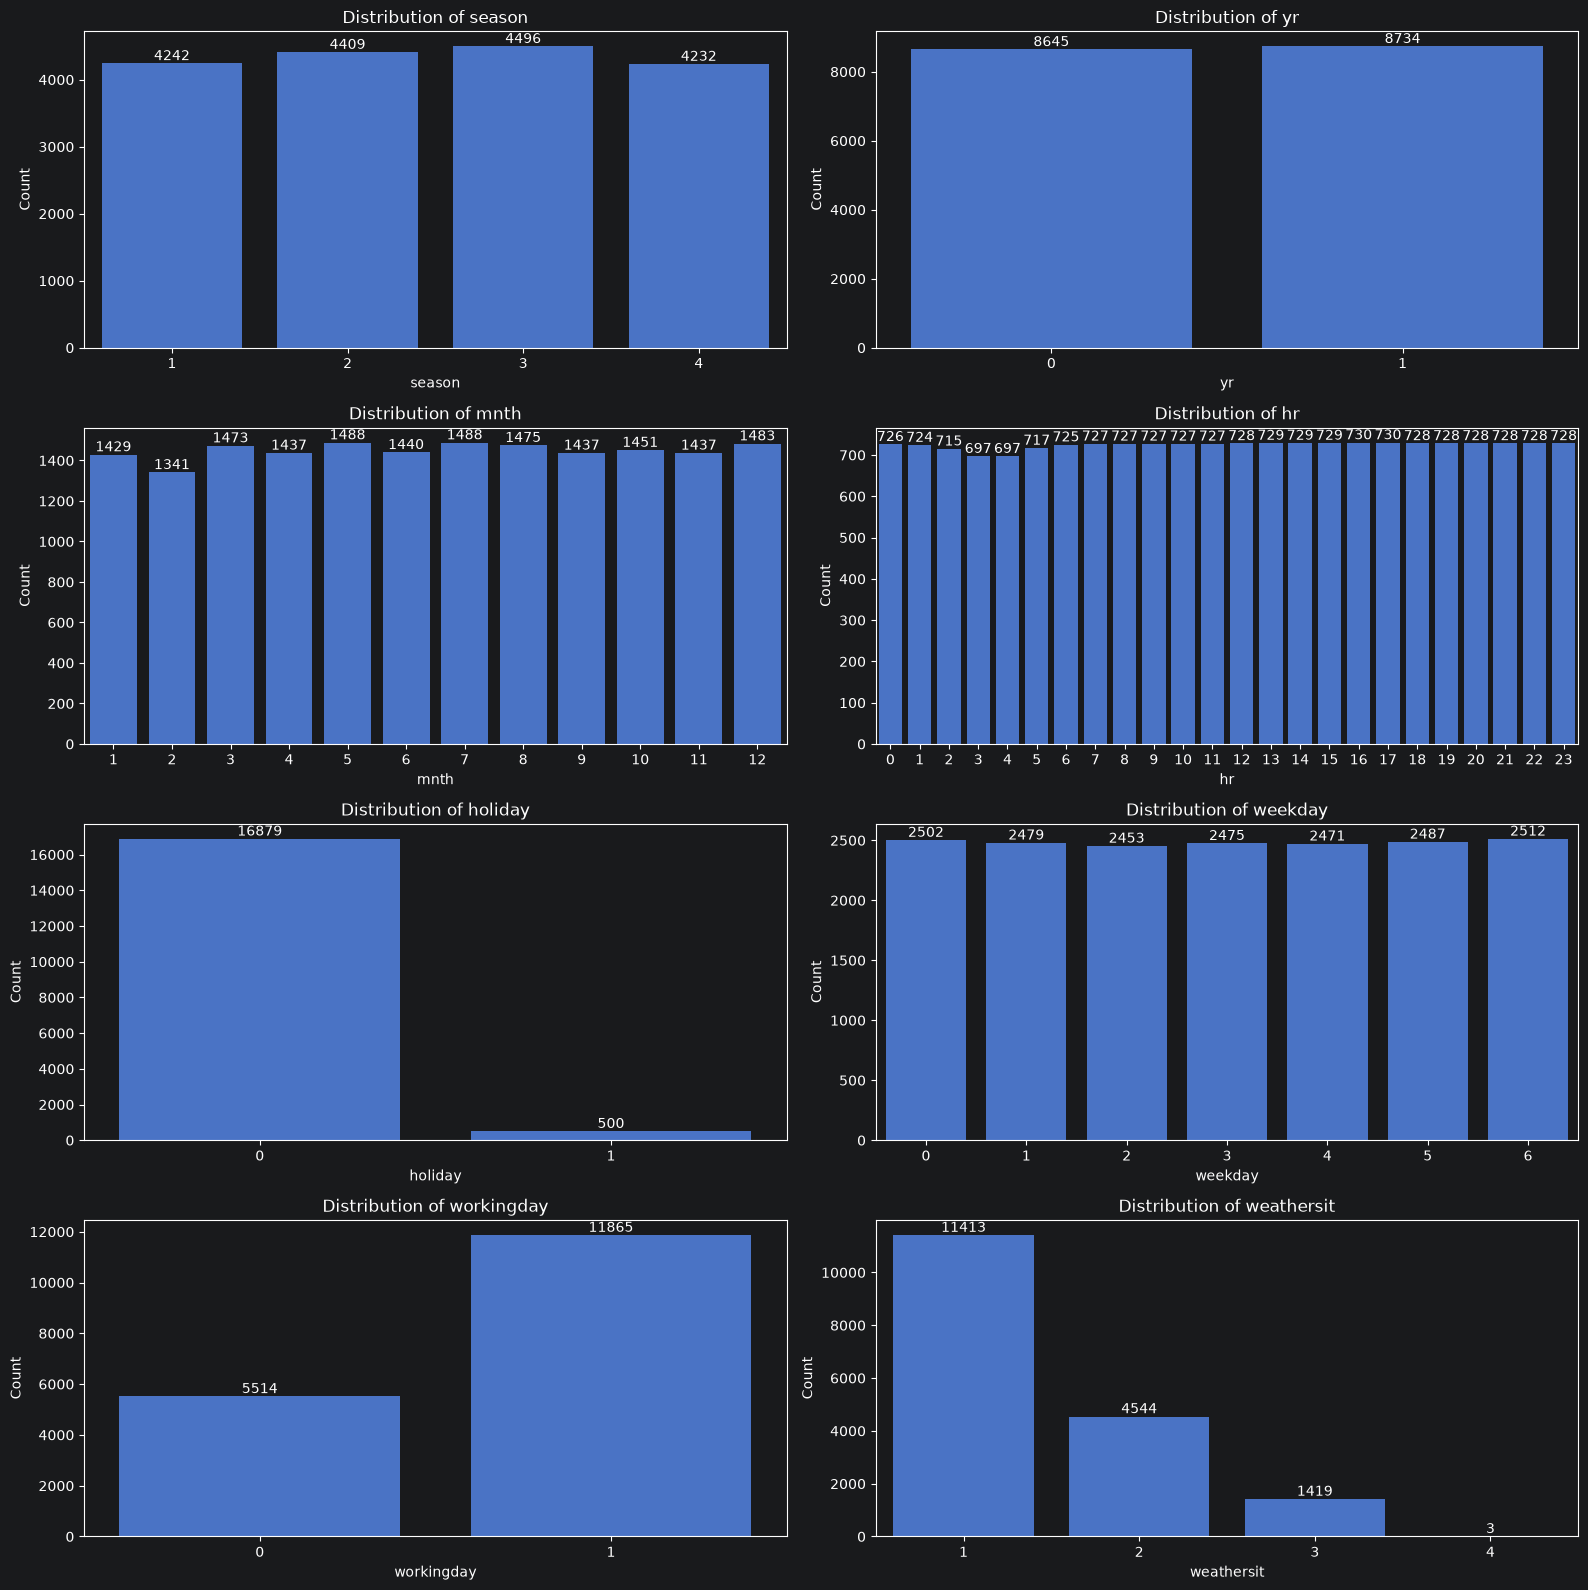

In [343]:
def plot_shape_cat(df,cat_cols):
    n_features = len(cat_cols)
    n_cols = 2
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        sns.countplot(
            data=df,
            x=col,
            ax=axes[i]
        )

        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        # Hiển thị số lượng trên từng cột
        for container in axes[i].containers:
            axes[i].bar_label(container)

    # Xóa subplot dư
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

plot_shape_cat(df,categorical_cols)

## 5. Exploratory Data Analysis

### 5.1 Target Distribution

#### ---- 1. Phân phối casual & registered (histogram + KDE) ----

In [344]:
analyze_shape_metrics(df,target_cols)

,skewness,skewness_interpretation,kurtosis,kurtosis_interpretation,recommendation
feature,,,,,
casual,2.499,Lệch phải (Mạnh),7.571,Đỉnh nhọn / Đuôi dày,Nên Log-transform hoặc Box-Cox trước khi train
registered,1.558,Lệch phải (Mạnh),2.750,Đỉnh nhọn / Đuôi dày,Nên Log-transform hoặc Box-Cox trước khi train


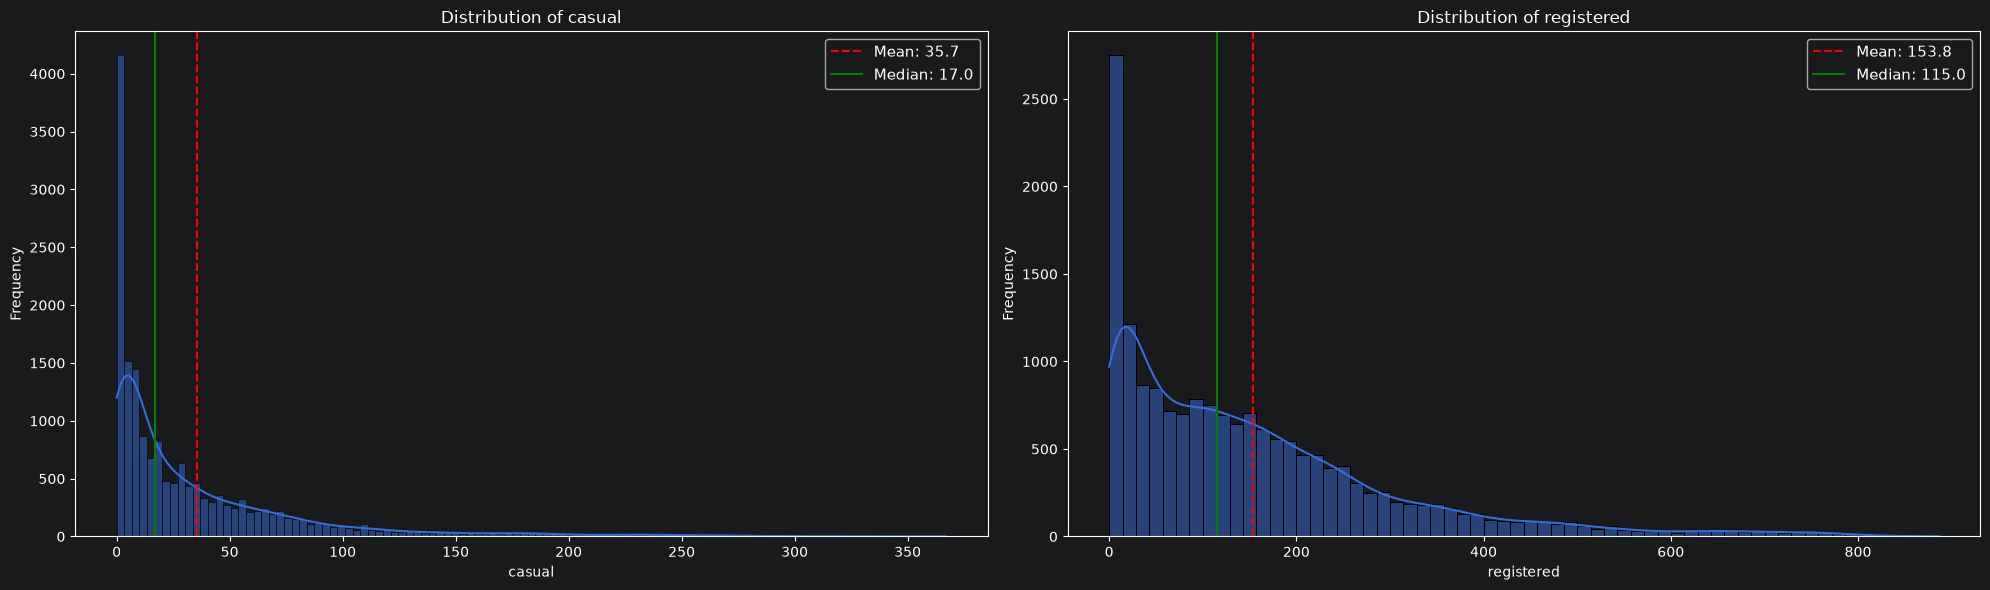

In [345]:
plot_data_shape(df,target_cols)

#### ---- 2. Boxplot để kiểm tra outliers ----

In [346]:
detect_outliers_report(df,target_cols)

,Feature,IQR Outliers (Count),IQR Outliers (%),Z-Score Outliers (Count),Z-Score Outliers (%)
0,casual,1192,6.86,467,2.69
1,registered,680,3.91,371,2.13


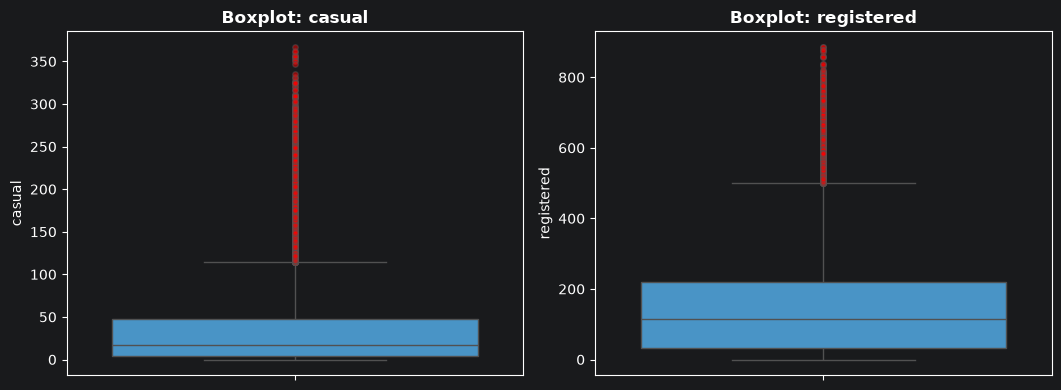

In [347]:
plot_box_num(df,target_cols)

#### ---- 5. So sánh mức độ biến động (CV) bằng biểu đồ ----

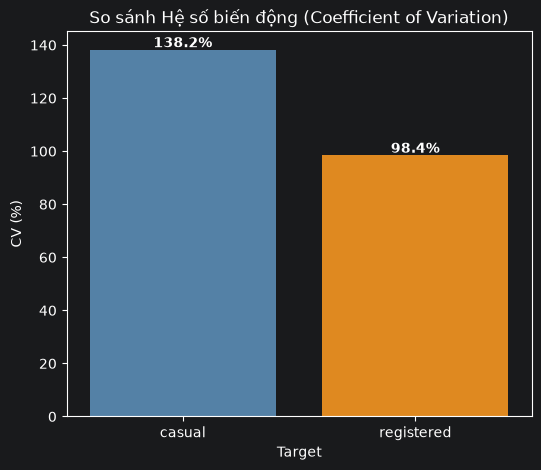

In [348]:
cv_data = pd.DataFrame({
    'Target': ['casual', 'registered'],
    'CV (%)': [
        df['casual'].std() / df['casual'].mean() * 100,
        df['registered'].std() / df['registered'].mean() * 100
    ]
})

plt.figure(figsize=(6, 5))
sns.barplot(data=cv_data, x='Target', y='CV (%)', palette=['steelblue', 'darkorange'], hue='Target')
plt.title('So sánh Hệ số biến động (Coefficient of Variation)')
plt.ylabel('CV (%)')
for i, v in enumerate(cv_data['CV (%)']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

### 5.2 Temporal Analysis

#### 5.2.1. Rental by `HOUR` (Casual vs Registered)

In [349]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
month_map = {i: m for i, m in enumerate(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], start=1)}

df['season_name'] = df['season'].map(season_map)
df['weekday_name'] = df['weekday'].map(weekday_map)
df['month_name'] = df['mnth'].map(month_map)

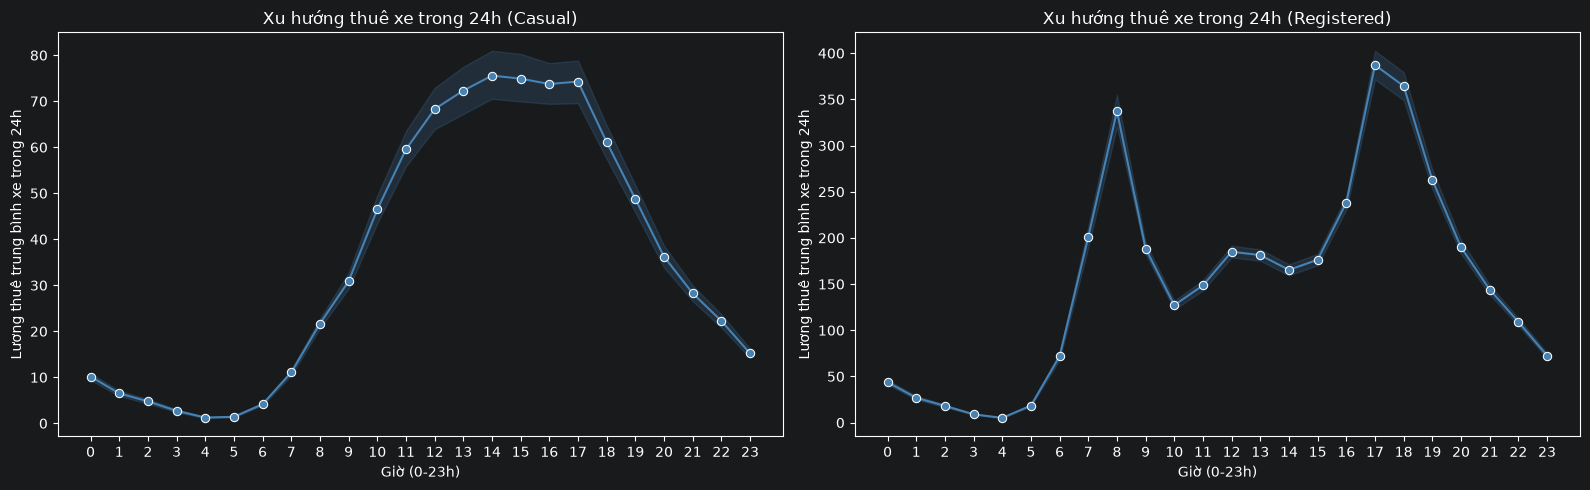

In [350]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(target_cols):
    sns.lineplot(data=df, x='hr',y=col, ax=axes[i],
             color='steelblue', errorbar=('ci', 95), marker='o')
    axes[i].set_title(f'Xu hướng thuê xe trong 24h ({col.capitalize()})')
    axes[i].set_xlabel('Giờ (0-23h)', fontsize=10)
    axes[i].set_ylabel('Lương thuê trung bình xe trong 24h', fontsize=10)
    axes[i].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

#### 5.2.2. Rental by `MONTH` (Casual vs Registered)

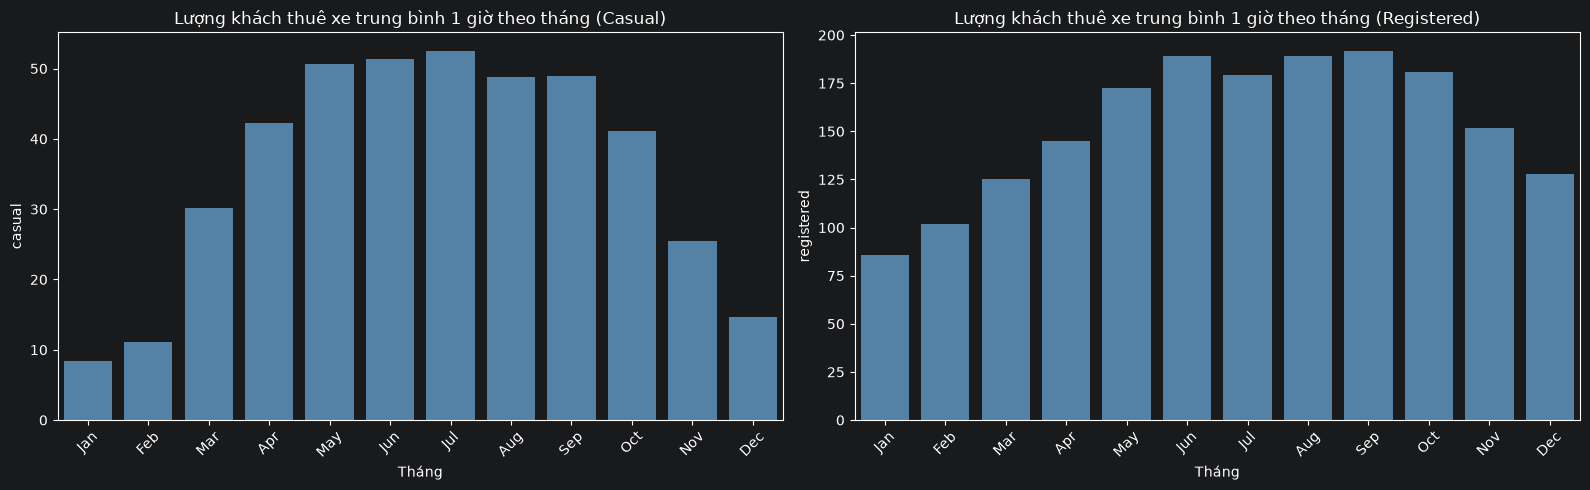

In [351]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(target_cols):
    sns.barplot(data=df, x='month_name', y=col, order=month_order,
            ax=axes[i], color='steelblue', errorbar=None)
    axes[i].set_title(f'Lượng khách thuê xe trung bình 1 giờ theo tháng ({col.capitalize()})')
    axes[i].set_xlabel('Tháng')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

#### 5.2.3. Rental by `WEEKDAY` (Casual vs Registered)

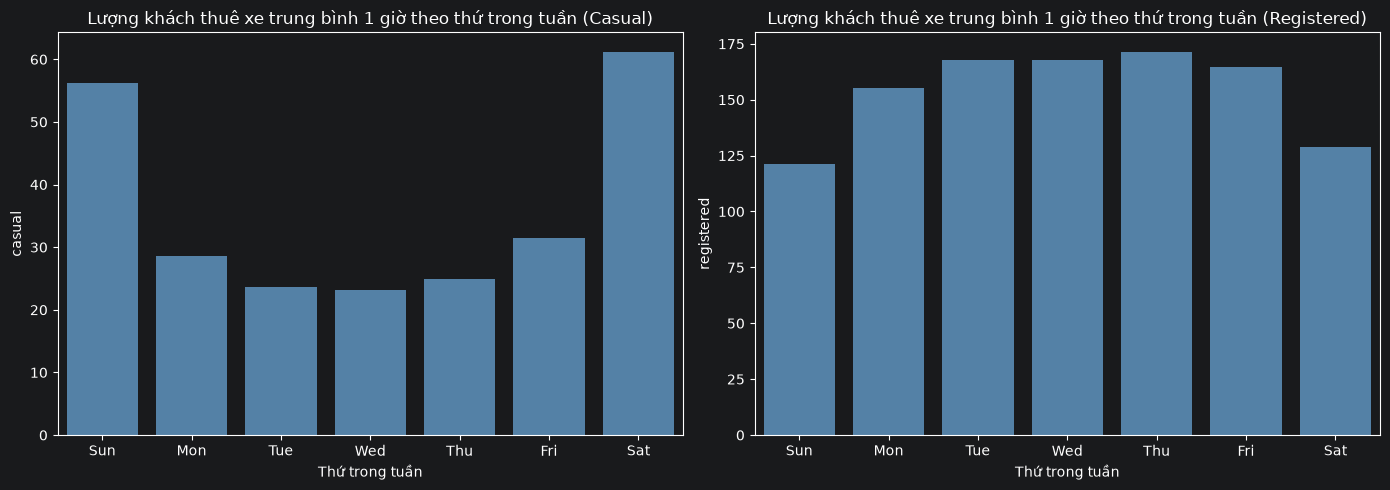

In [352]:
weekday_order = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i,col in enumerate(target_cols):
    sns.barplot(data=df, x='weekday_name', y=col, order=weekday_order,
            ax=axes[i], color='steelblue', errorbar=None)
    axes[i].set_title(f'Lượng khách thuê xe trung bình 1 giờ theo thứ trong tuần ({col.capitalize()})')
    axes[i].set_xlabel('Thứ trong tuần')

plt.tight_layout()
plt.show()

#### 5.2.4. Rental by `SEASON`

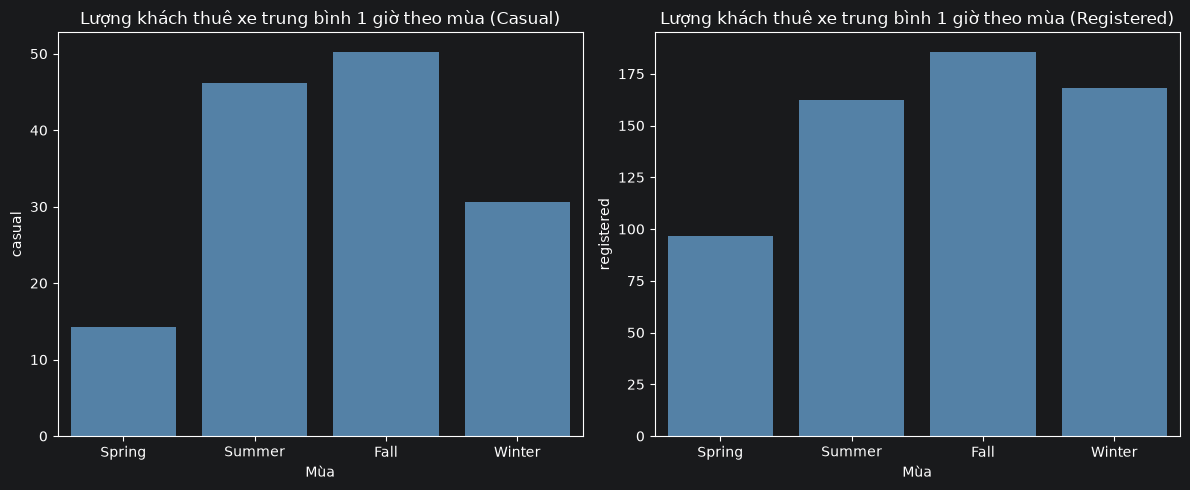

In [353]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i,col in enumerate(target_cols):

    sns.barplot(data=df, x='season_name', y=col, order=season_order,
                ax=axes[i], color='steelblue', errorbar=None)
    axes[i].set_title(f'Lượng khách thuê xe trung bình 1 giờ theo mùa ({col.capitalize()})')
    axes[i].set_xlabel('Mùa')

plt.tight_layout()
plt.show()

#### 5.2.5.Tổng hợp — so sánh xu hướng theo tháng qua các năm

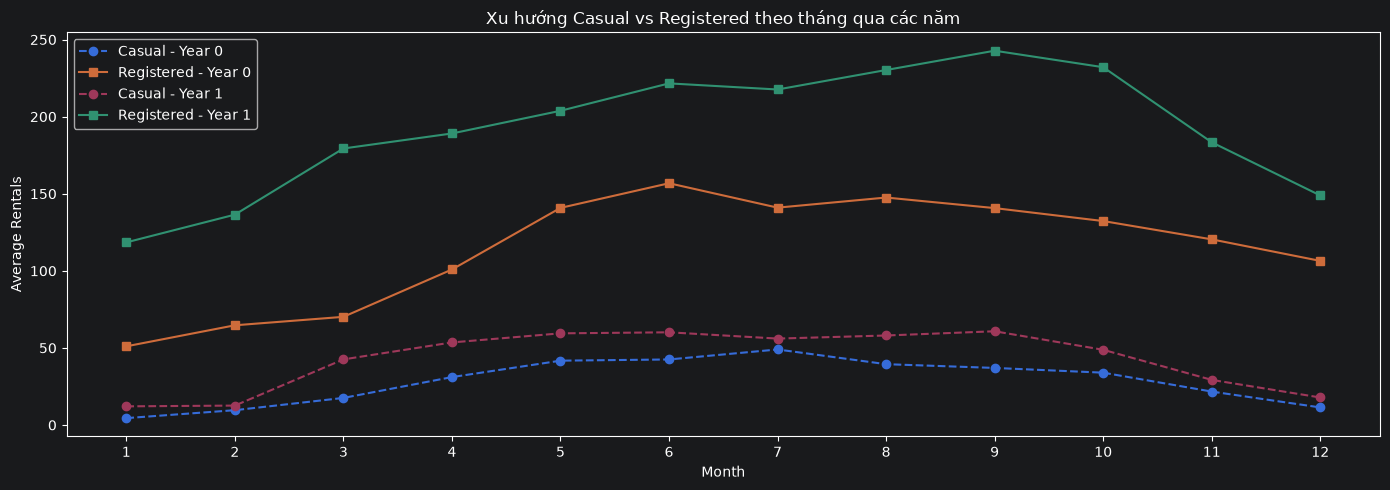

In [354]:
if 'yr' in df.columns:
    monthly_avg = df.groupby(['yr', 'mnth'])[['casual', 'registered']].mean().reset_index()
    fig, ax = plt.subplots(figsize=(14, 5))
    for yr_val, grp in monthly_avg.groupby('yr'):
        ax.plot(grp['mnth'], grp['casual'], marker='o', linestyle='--',
                label=f'Casual - Year {yr_val}')
        ax.plot(grp['mnth'], grp['registered'], marker='s',
                label=f'Registered - Year {yr_val}')
    ax.set_title('Xu hướng Casual vs Registered theo tháng qua các năm')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Rentals')
    ax.set_xticks(range(1, 13))
    ax.legend()
    plt.tight_layout()
    plt.show()

- Giải thích:
    - Nhìn biểu đồ cho ta thấy được ngày không đi làm và ngày lể lượng khách vãn lai thuê xe tăng mạnh
    - Còn khách đã đăng ký hội viên thì ngày không đi làm với ngày lể mới giảm còn ngày đi làm thìm nó có xu hướng chu kỳ bắt đầu tăng mạnh ở móc 7h đén 9h và từ 16h-18h

### 5.3 Calendar & Working Pattern

#### 5.3.1. Casual & Registered: Working Day vs Non-working Day

In [355]:
# Map lại cho dễ đọc
workingday_map = {0: 'Non-working Day', 1: 'Working Day'}
holiday_map = {0: 'Non-holiday', 1: 'Holiday'}

df['workingday_name'] = df['workingday'].map(workingday_map)
df['holiday_name'] = df['holiday'].map(holiday_map)

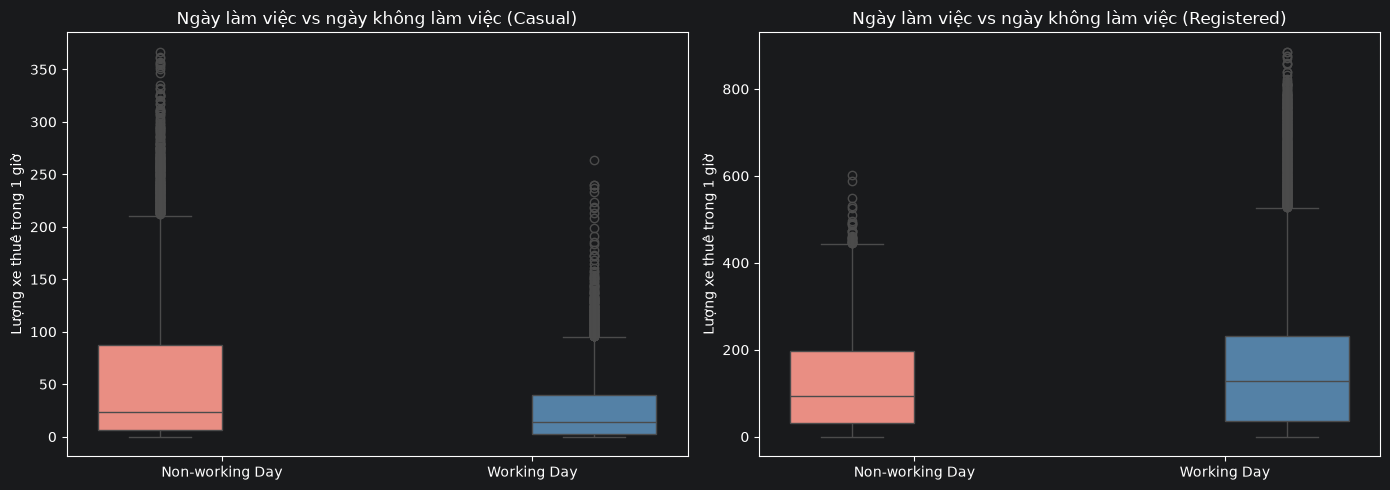

In [356]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(target_cols):
    sns.boxplot(data=df, x='workingday_name', y=col, ax=axes[i],
            palette=['salmon', 'steelblue'],hue='workingday_name',)
    axes[i].set_title(f'Ngày làm việc vs ngày không làm việc ({col.capitalize()})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Lượng xe thuê trong 1 giờ')

plt.tight_layout()
plt.show()

#### 5.3.2. Casual & Registered: Holiday vs Non-holiday

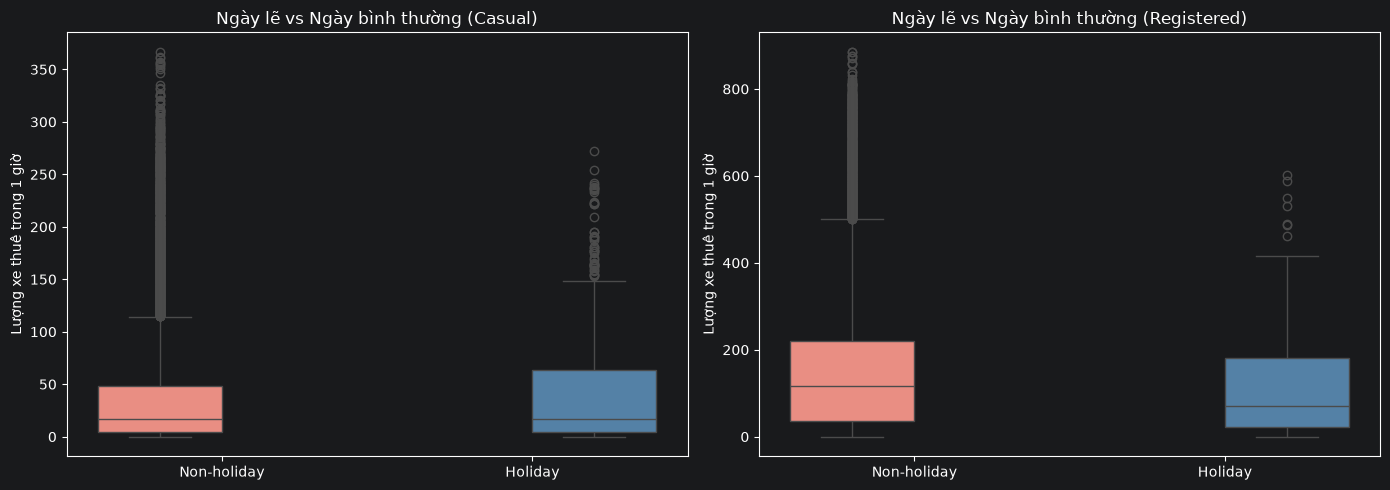

In [357]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(target_cols):
    sns.boxplot(data=df, x='holiday_name', y=col, ax=axes[i],
            palette=['salmon', 'steelblue'],hue='holiday_name',)
    axes[i].set_title(f'Ngày lẽ vs Ngày bình thường ({col.capitalize()})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Lượng xe thuê trong 1 giờ')

plt.tight_layout()
plt.show()

#### 5.3.3. Bảng thống kê trung bình để hỗ trợ đọc biểu đồ

In [358]:
print("=== Trung bình theo Working Day ===")
print(df.groupby('workingday_name')[['casual', 'registered']].mean())

print("\n=== Trung bình theo Holiday ===")
print(df.groupby('holiday_name')[['casual', 'registered']].mean())

=== Trung bình theo Working Day ===
                    casual  registered
workingday_name                       
Non-working Day  57.441422  123.963910
Working Day      25.561315  167.646439

=== Trung bình theo Holiday ===
                 casual  registered
holiday_name                       
Non-holiday   35.408377  155.020203
Holiday       44.718000  112.152000


#### 5.3.4. HOURLY PATTERN: Working Day vs Non-working Day

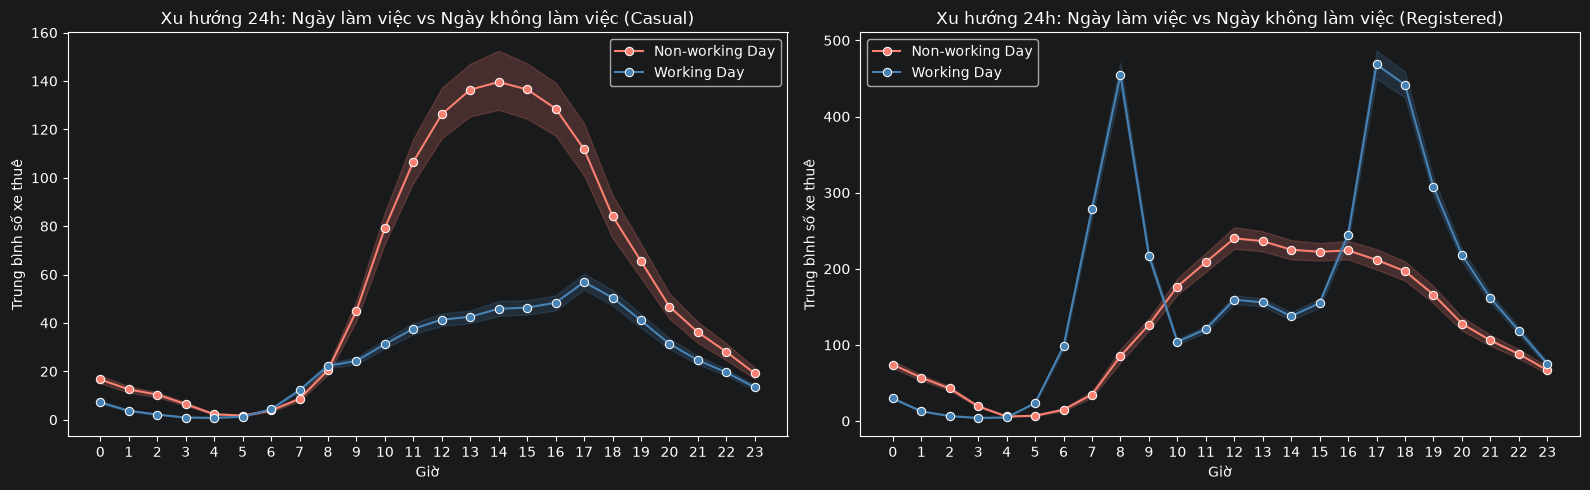

In [359]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for i, col in enumerate(target_cols):
    sns.lineplot(data=df, x='hr', y=col, hue='workingday_name',
             ax=axes[i], marker='o', errorbar=('ci', 95),
             palette=['salmon', 'steelblue'])
    axes[i].set_title(f'Xu hướng 24h: Ngày làm việc vs Ngày không làm việc ({col.capitalize()})')
    axes[i].set_xlabel('Giờ')
    axes[i].set_ylabel('Trung bình số xe thuê')
    axes[i].set_xticks(range(0, 24))
    axes[i].legend(title='')


plt.tight_layout()
plt.show()

#### 5.3.5. Xác định khung giờ cao điểm (Top 3 giờ) theo từng loại ngày

In [360]:
peak_hours = df.groupby(['workingday_name', 'hr'])[['casual', 'registered']].mean().reset_index()

print("\n=== Top 3 giờ cao điểm - Casual (Working Day) ===")
print(peak_hours[peak_hours['workingday_name']=='Working Day']
      .nlargest(3, 'casual')[['hr', 'casual']])

print("\n=== Top 3 giờ cao điểm - Casual (Non-working Day) ===")
print(peak_hours[peak_hours['workingday_name']=='Non-working Day']
      .nlargest(3, 'casual')[['hr', 'casual']])

print("\n=== Top 3 giờ cao điểm - Registered (Working Day) ===")
print(peak_hours[peak_hours['workingday_name']=='Working Day']
      .nlargest(3, 'registered')[['hr', 'registered']])

print("\n=== Top 3 giờ cao điểm - Registered (Non-working Day) ===")
print(peak_hours[peak_hours['workingday_name']=='Non-working Day']
      .nlargest(3, 'registered')[['hr', 'registered']])


=== Top 3 giờ cao điểm - Casual (Working Day) ===
    hr     casual
41  17  56.895792
42  18  50.451807
40  16  48.344689

=== Top 3 giờ cao điểm - Casual (Non-working Day) ===
    hr      casual
14  14  139.593074
15  15  136.502165
13  13  136.424242

=== Top 3 giờ cao điểm - Registered (Working Day) ===
    hr  registered
41  17  468.394790
32   8  454.741935
42  18  441.775100

=== Top 3 giờ cao điểm - Registered (Non-working Day) ===
    hr  registered
12  12  240.012987
13  13  236.307359
14  14  225.051948


### 5.4 User Behavior Analysis

#### 5.4.1. Casual vs Registered by HOUR

In [361]:
df_melt = df.melt(
    id_vars=['hr', 'weekday_name', 'season_name', 'workingday_name', 'holiday_name'],
    value_vars=['casual', 'registered'],
    var_name='user_type',
    value_name='rentals'
)

user_palette = {'casual': 'steelblue', 'registered': 'darkorange'}

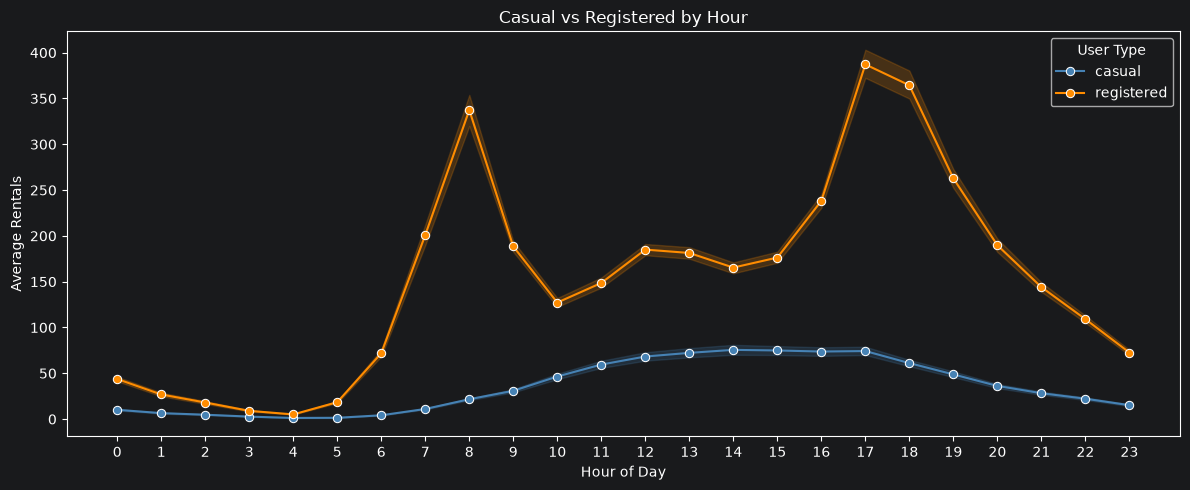

In [362]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_melt, x='hr', y='rentals', hue='user_type',
             marker='o', errorbar=('ci', 95), palette=user_palette)
plt.title('Casual vs Registered by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

#### 5.4.2. Casual vs Registered by WEEKDAY

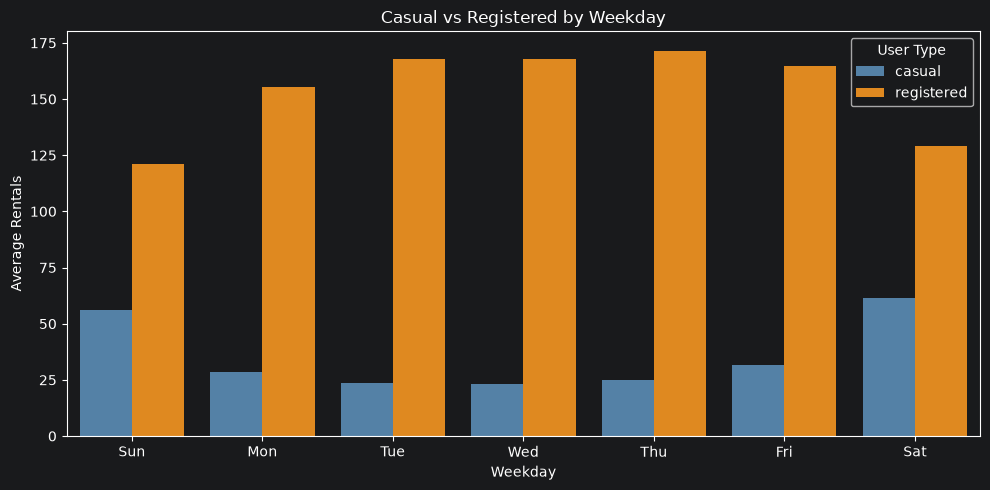

In [363]:

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x='weekday_name', y='rentals', hue='user_type',
            order=weekday_order, errorbar=None, palette=user_palette)
plt.title('Casual vs Registered by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Rentals')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

#### 5.4.3. Casual vs Registered by SEASON

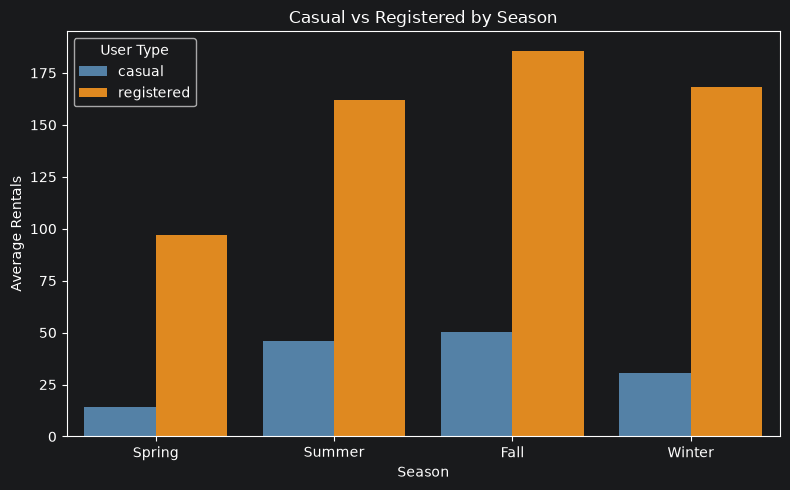

In [364]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melt, x='season_name', y='rentals', hue='user_type',
            order=season_order, errorbar=None, palette=user_palette)
plt.title('Casual vs Registered by Season')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

#### 5.4.4. Casual vs Registered on WORKING DAYS

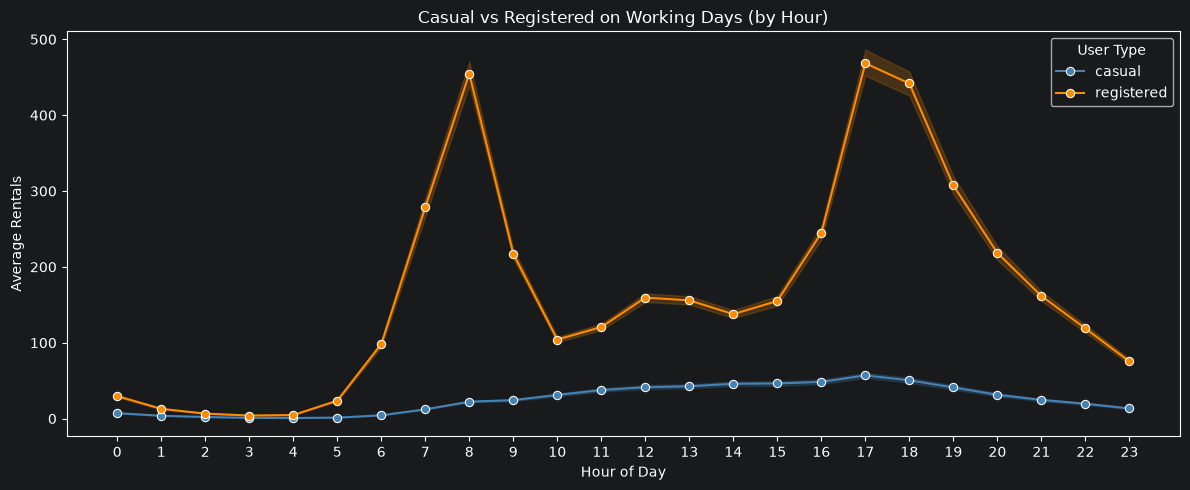

In [365]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_melt[df_melt['workingday_name'] == 'Working Day'],
    x='hr', y='rentals', hue='user_type',
    marker='o', errorbar=('ci', 95), palette=user_palette
)
plt.title('Casual vs Registered on Working Days (by Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

#### 5.4.5. Casual vs Registered on HOLIDAYS (hourly)

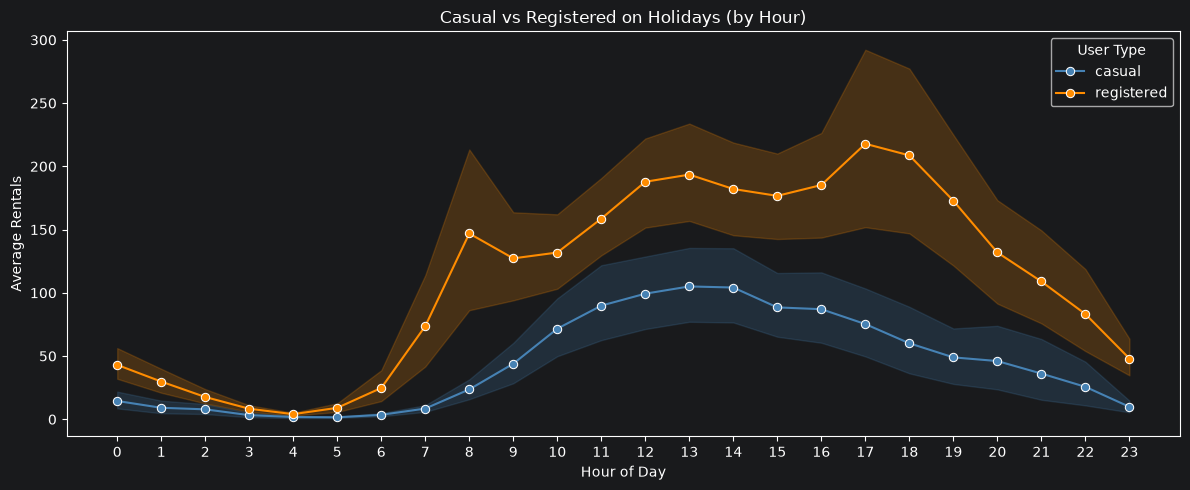

In [366]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_melt[df_melt['holiday_name'] == 'Holiday'],
    x='hr', y='rentals', hue='user_type',
    marker='o', errorbar=('ci', 95), palette=user_palette
)
plt.title('Casual vs Registered on Holidays (by Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

#### 5.4.6. Tỷ lệ đóng góp Casual vs Registered trong tổng lượt thuê

In [367]:
total_casual = df['casual'].sum()
total_registered = df['registered'].sum()
total = total_casual + total_registered

print("=== Tỷ trọng đóng góp vào tổng lượt thuê ===")
print(f"Casual     : {total_casual:,} ({total_casual/total*100:.1f}%)")
print(f"Registered : {total_registered:,} ({total_registered/total*100:.1f}%)")


=== Tỷ trọng đóng góp vào tổng lượt thuê ===
Casual     : 620,017 (18.8%)
Registered : 2,672,662 (81.2%)


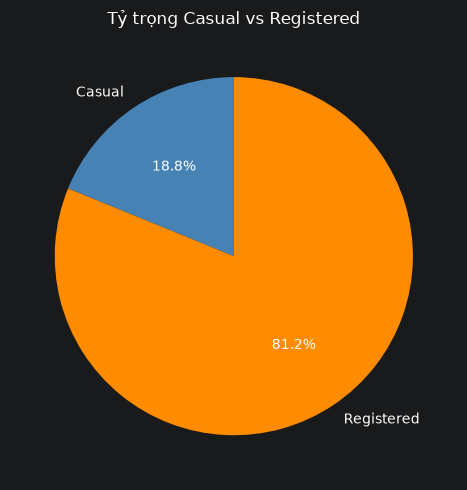

In [368]:
plt.figure(figsize=(5, 5))
plt.pie([total_casual, total_registered],
        labels=['Casual', 'Registered'],
        autopct='%1.1f%%',
        colors=['steelblue', 'darkorange'],
        startangle=90)
plt.title('Tỷ trọng Casual vs Registered')
plt.tight_layout()
plt.show()

#### 5.4.7. Tỷ lệ casual/registered thay đổi theo giờ

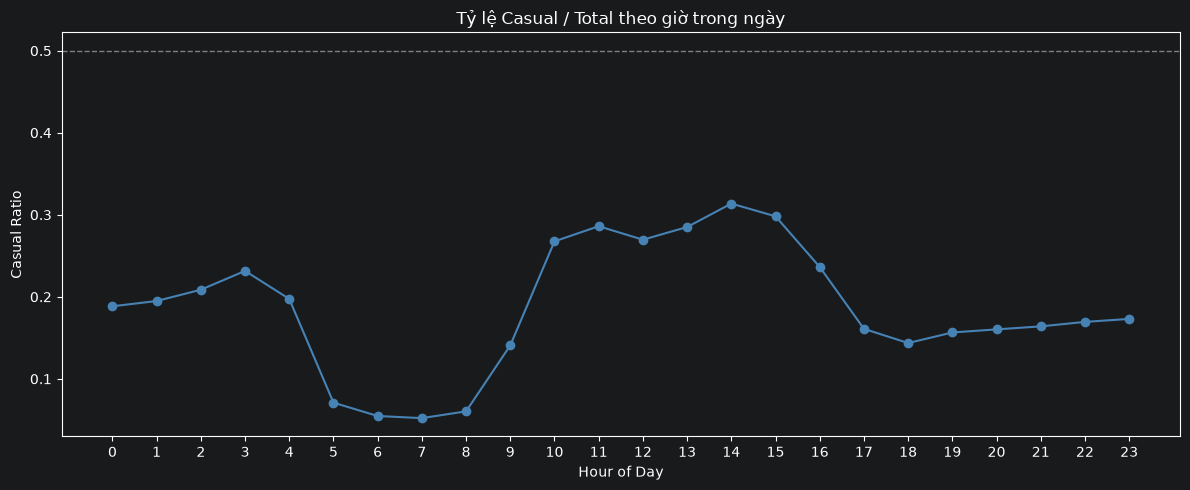

In [369]:
ratio_by_hour = df.groupby('hr')[['casual', 'registered']].mean()
ratio_by_hour['casual_ratio'] = ratio_by_hour['casual'] / (ratio_by_hour['casual'] + ratio_by_hour['registered'])

plt.figure(figsize=(12, 5))
plt.plot(ratio_by_hour.index, ratio_by_hour['casual_ratio'], marker='o', color='steelblue')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Tỷ lệ Casual / Total theo giờ trong ngày')
plt.xlabel('Hour of Day')
plt.ylabel('Casual Ratio')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 5.5 Weather Analysis

#### 5.5.1. Rental by TEMPERATURE

In [370]:
df['temp_actual'] = df['temp'] * 41
df['hum_actual'] = df['hum'] * 100
df['windspeed_actual'] = df['windspeed'] * 6
weathersit_map = {
    1: 'Clear/Few clouds',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Storm'
}
df['weathersit_name'] = df['weathersit'].map(weathersit_map)

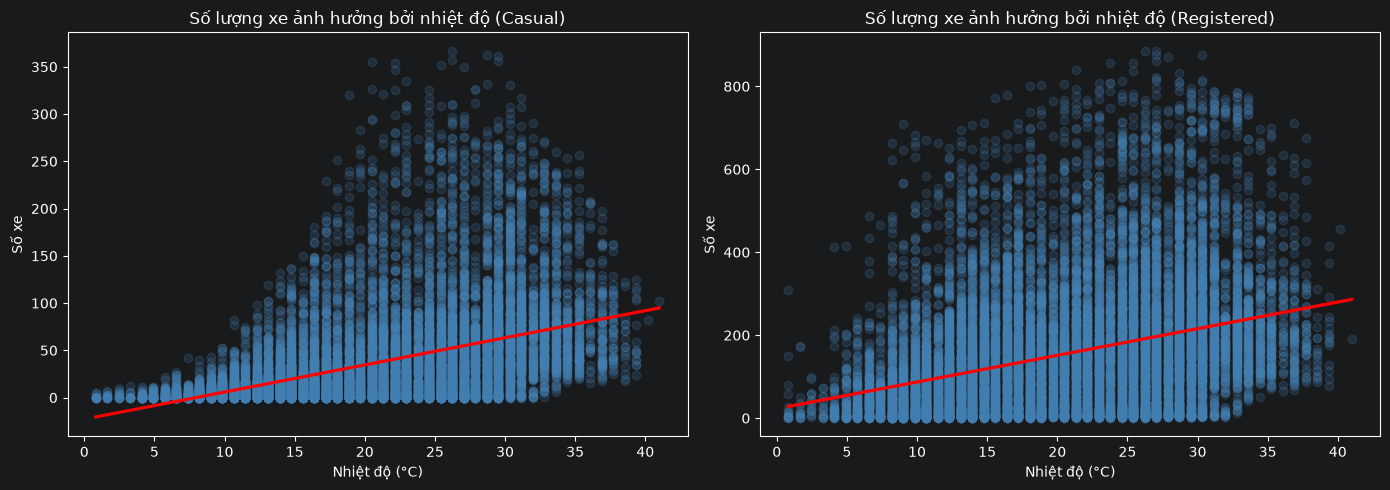

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i,col in enumerate(target_cols):
    sns.regplot(data=df, x='temp_actual', y=col, ax=axes[i],
            scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
            line_kws={'color': 'red'})
    axes[i].set_title(f'Số lượng xe ảnh hưởng bởi nhiệt độ ({col.capitalize()})')
    axes[i].set_xlabel('Nhiệt độ (°C)')
    axes[i].set_ylabel('Số xe')

plt.tight_layout()
plt.show()

#### 5.5.2. Rental by HUMIDITY

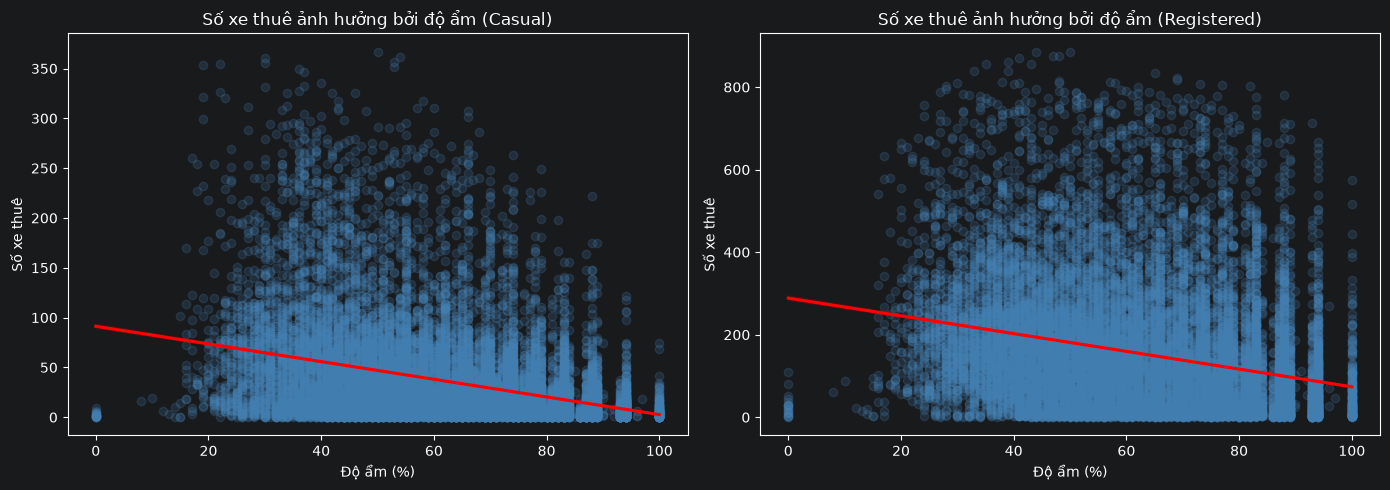

In [372]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i,col in enumerate(target_cols):
    sns.regplot(data=df, x='hum_actual', y=col, ax=axes[i],
            scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
            line_kws={'color': 'red'})
    axes[i].set_title(f'Số xe thuê ảnh hưởng bởi độ ẩm ({col.capitalize()})')
    axes[i].set_xlabel('Độ ẩm (%)')
    axes[i].set_ylabel('Số xe thuê')

plt.tight_layout()
plt.show()

#### 5.5.3. Rental by WIND SPEED

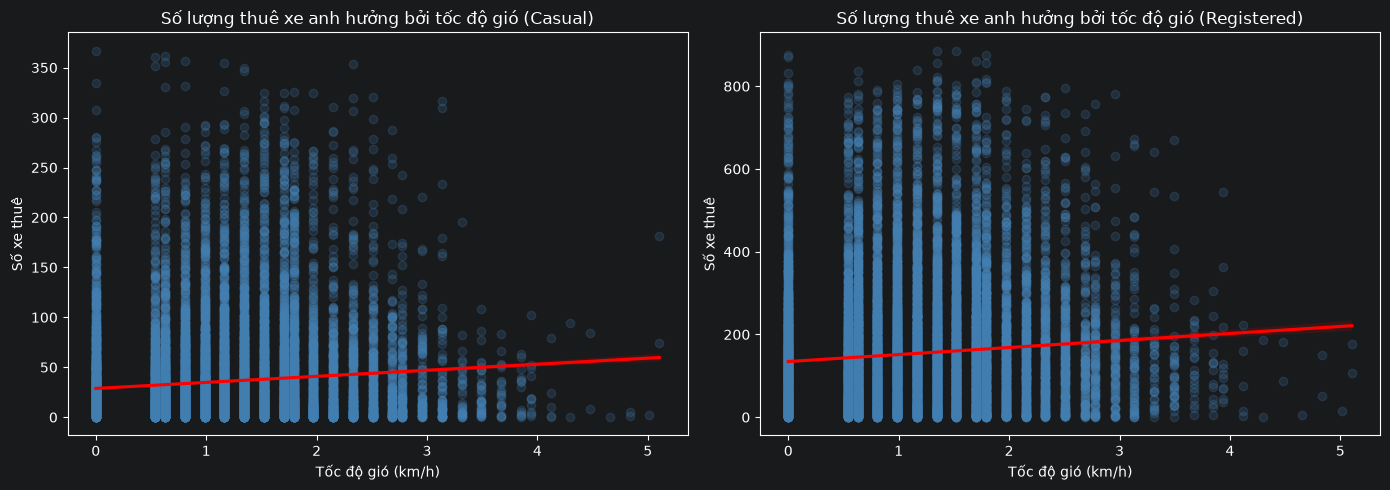

In [373]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i,col in enumerate(target_cols):
    sns.regplot(data=df, x='windspeed_actual', y=col, ax=axes[i],
            scatter_kws={'alpha': 0.2, 'color': 'steelblue'},
            line_kws={'color': 'red'})
    axes[i].set_title(f'Số lượng thuê xe anh hưởng bởi tốc độ gió ({col.capitalize()})')
    axes[i].set_xlabel('Tốc độ gió (km/h)')
    axes[i].set_ylabel('Số xe thuê')

plt.tight_layout()
plt.show()

#### 5.5.4. Rental by WEATHER SITUATION

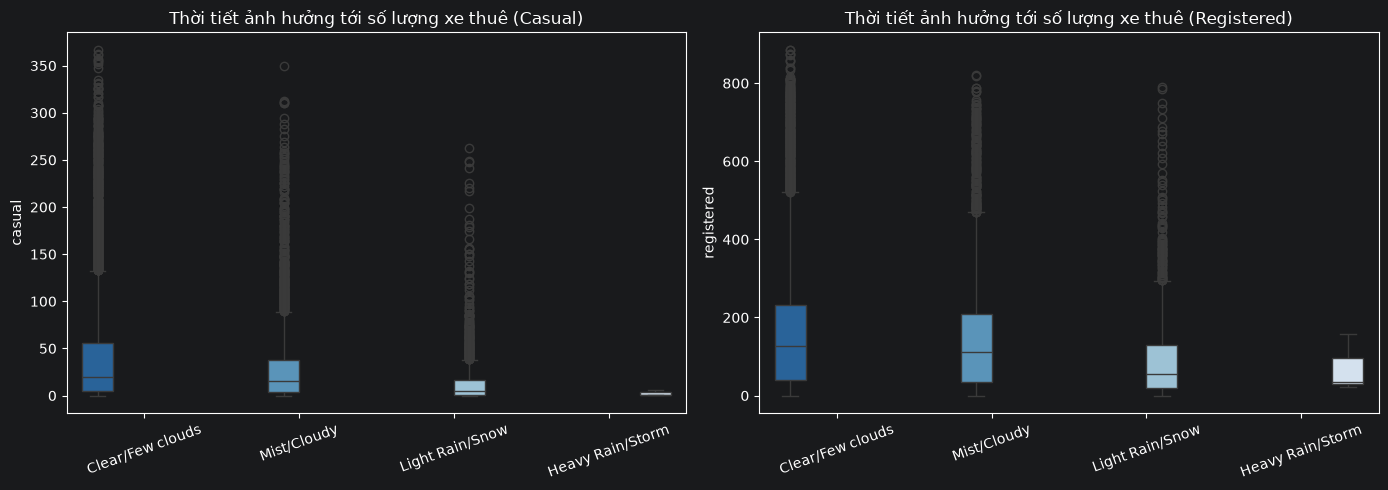

In [374]:
weather_order = ['Clear/Few clouds', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Storm']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i,col in enumerate(target_cols):
    sns.boxplot(data=df, x='weathersit_name', y=col, order=weather_order,
            ax=axes[i], palette='Blues_r',hue='weathersit_name',)
    axes[i].set_title(f'Thời tiết ảnh hưởng tới số lượng xe thuê ({col.capitalize()})')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 5.5.5. Bảng thống kê trung bình theo Weather Situation

In [375]:
print("=== Trung bình Casual & Registered theo Weather Situation ===")
print(df.groupby('weathersit_name')[['casual', 'registered']].mean().reindex(weather_order))


=== Trung bình Casual & Registered theo Weather Situation ===
                     casual  registered
weathersit_name                        
Clear/Few clouds  40.545431  164.323841
Mist/Cloudy       29.595290  145.570202
Light Rain/Snow   16.055673   95.523608
Heavy Rain/Storm   2.666667   71.666667


### 5.5.6. Hệ số tương quan Pearson: weather features vs targets


=== Tương quan giữa yếu tố thời tiết và targets ===
                    casual  registered
temp_actual       0.459616    0.335361
hum_actual       -0.347028   -0.273933
windspeed_actual  0.090287    0.082321


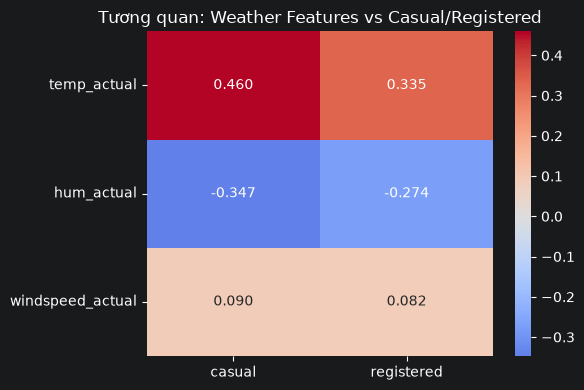

In [376]:
weather_features = ['temp_actual', 'hum_actual', 'windspeed_actual']
corr_weather = df[weather_features + ['casual', 'registered']].corr()[['casual', 'registered']].loc[weather_features]

print("\n=== Tương quan giữa yếu tố thời tiết và targets ===")
print(corr_weather)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_weather, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Tương quan: Weather Features vs Casual/Registered')
plt.tight_layout()
plt.show()

#### 5.4.7. Nhiệt độ vs Rentals, phân theo Weather Situation

In [377]:
weather_palette = {
    'Clear/Few clouds': '#2ecc71',    # xanh lá - trời đẹp
    'Mist/Cloudy':      '#f1c40f',    # vàng - âm u
    'Light Rain/Snow':  '#3498db',    # xanh dương - mưa nhẹ
    'Heavy Rain/Storm': '#e74c3c'     # đỏ - bão/mưa nặng
}

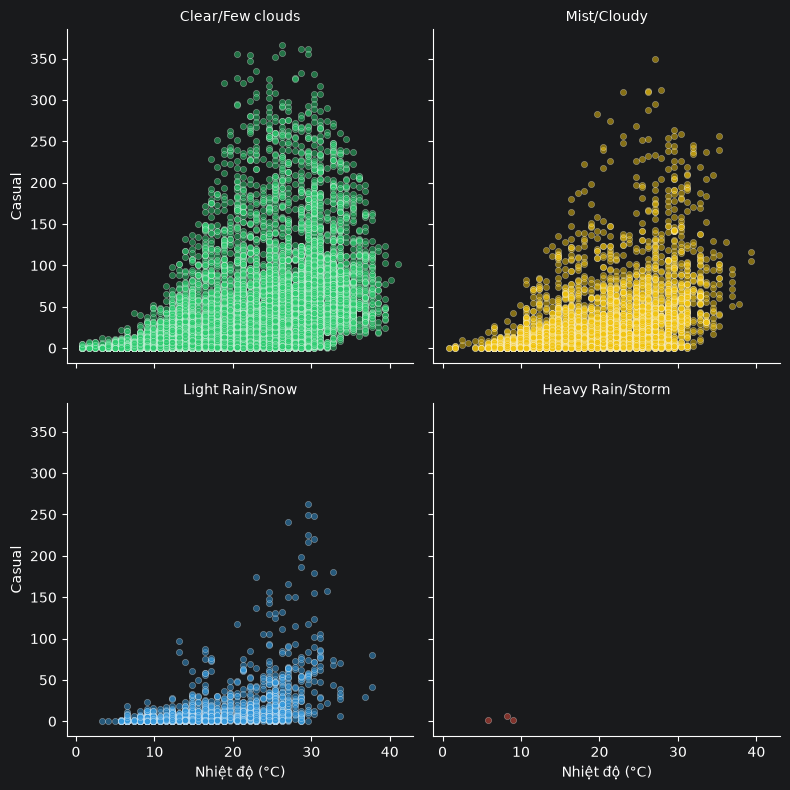

In [378]:
g = sns.FacetGrid(df, col='weathersit_name', col_order=weather_order,
                   col_wrap=2, height=4, hue='weathersit_name',
                   palette=weather_palette)
g.map_dataframe(sns.scatterplot, x='temp_actual', y='casual', alpha=0.5, s=20)
g.set_axis_labels('Nhiệt độ (°C)', 'Casual')
g.set_titles(col_template='{col_name}')
plt.tight_layout()
plt.show()

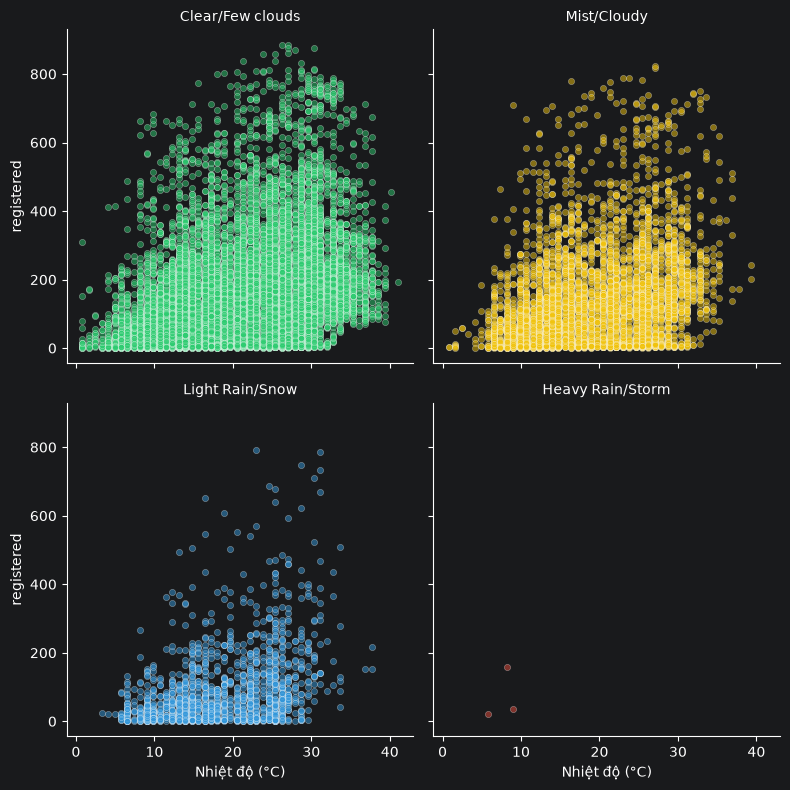

In [379]:
g = sns.FacetGrid(df, col='weathersit_name', col_order=weather_order,
                   col_wrap=2, height=4, hue='weathersit_name',
                   palette=weather_palette)
g.map_dataframe(sns.scatterplot, x='temp_actual', y='registered', alpha=0.5, s=20)
g.set_axis_labels('Nhiệt độ (°C)', 'registered')
g.set_titles(col_template='{col_name}')
plt.tight_layout()
plt.show()

### 5.6 Correlation Analysis

In [380]:
df.select_dtypes(include='number').columns

Index(['instant', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered',
       'cnt', 'temp_actual', 'hum_actual', 'windspeed_actual'],
      dtype='str')

In [381]:
numerical_cols = df.select_dtypes(include='number').drop(columns=['instant','hum_actual','windspeed_actual','temp_actual'], errors='ignore').columns.tolist()

#### 5.6.1. Correlation Matrix tổng thể
- chú thích:
    - Biết các biến number là dạng phi tuyến tính nên dùng hệ số spearman  thay cho Pearson

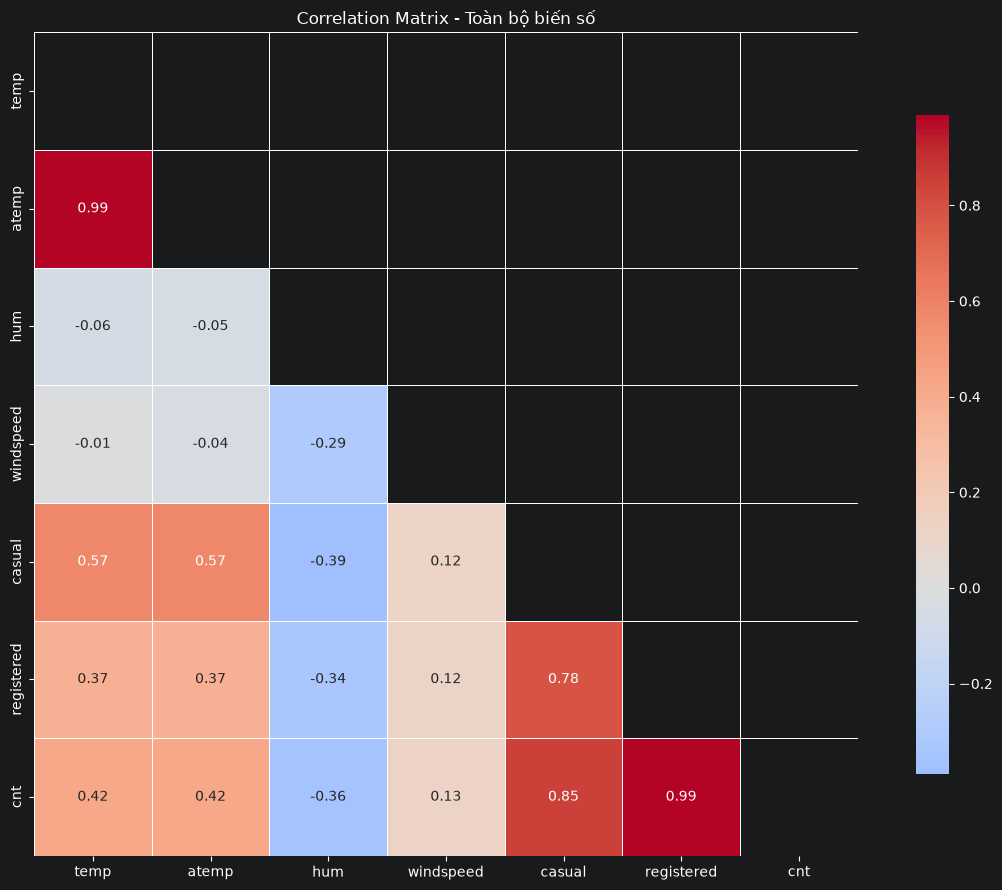

In [382]:
corr_matrix = df[numerical_cols].corr(method='spearman')

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # chỉ hiện nửa tam giác dưới
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Toàn bộ biến số')
plt.tight_layout()
plt.show()

#### 5.6.2. Correlation giữa numerical features và CASUAL

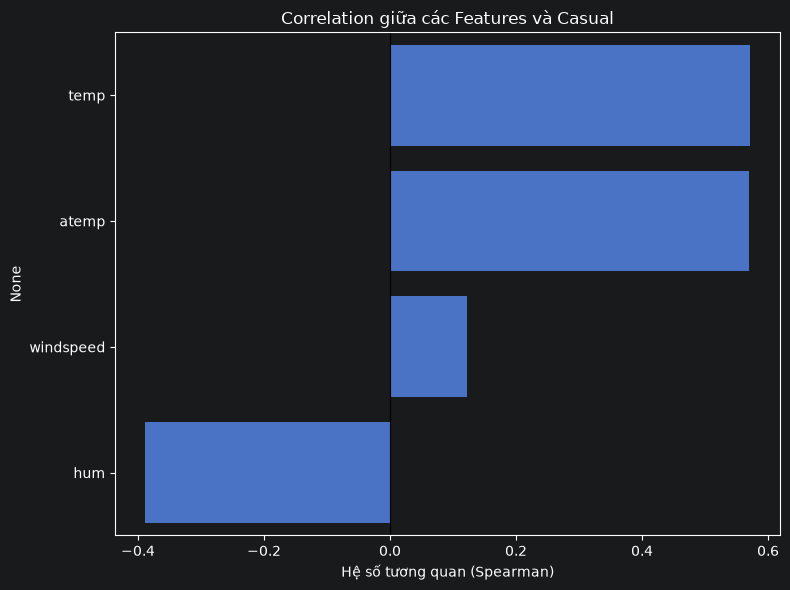

In [383]:
corr_casual = corr_matrix['casual'].drop(['casual', 'registered', 'cnt'], errors='ignore') \
                                    .sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_casual.values, y=corr_casual.index)
plt.title('Correlation giữa các Features và Casual')
plt.xlabel('Hệ số tương quan (Spearman)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [384]:
print("=== Tương quan với Casual (sắp xếp giảm dần) ===")
print(corr_casual)

=== Tương quan với Casual (sắp xếp giảm dần) ===
temp         0.570989
atemp        0.570419
windspeed    0.122920
hum         -0.388213
Name: casual, dtype: float64


#### 5.6.3. Correlation giữa numerical features và REGISTERED

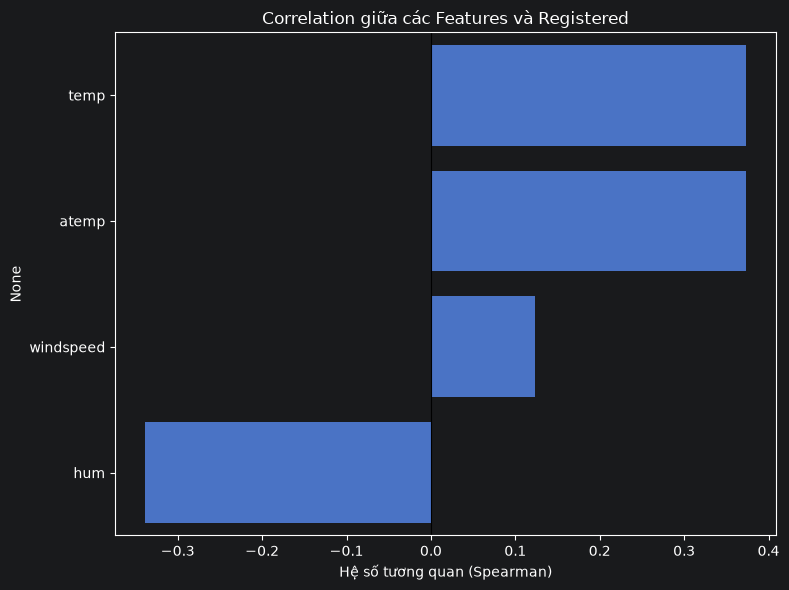

In [385]:
corr_registered = corr_matrix['registered'].drop(['casual', 'registered', 'cnt'], errors='ignore') \
                                            .sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_registered.values, y=corr_registered.index)
plt.title('Correlation giữa các Features và Registered')
plt.xlabel('Hệ số tương quan (Spearman)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [386]:

print("\n=== Tương quan với Registered (sắp xếp giảm dần) ===")
print(corr_registered)


=== Tương quan với Registered (sắp xếp giảm dần) ===
temp         0.373196
atemp        0.373014
windspeed    0.122936
hum         -0.338480
Name: registered, dtype: float64


#### 5.6.4. So sánh trực tiếp: Casual vs Registered correlation

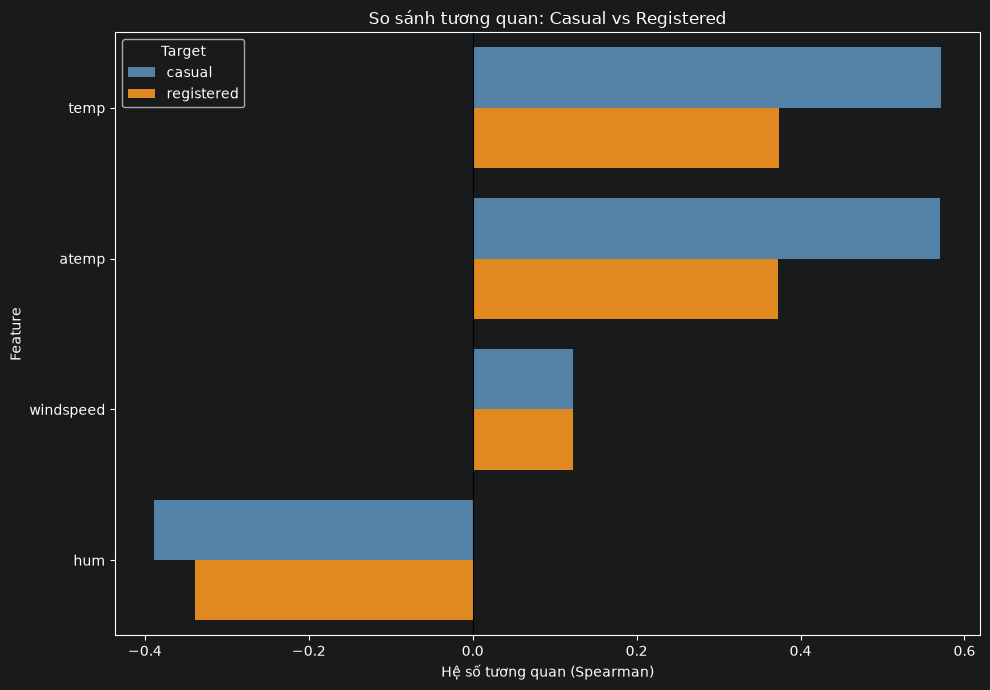

In [387]:
compare_corr = pd.DataFrame({
    'casual': corr_casual,
    'registered': corr_registered
}).sort_values(by='casual', ascending=False)

compare_corr_melt = compare_corr.reset_index().melt(
    id_vars='index', var_name='target', value_name='correlation'
)

plt.figure(figsize=(10, 7))
sns.barplot(data=compare_corr_melt, y='index', x='correlation', hue='target',
            palette={'casual': 'steelblue', 'registered': 'darkorange'})
plt.title('So sánh tương quan: Casual vs Registered')
plt.xlabel('Hệ số tương quan (Spearman)')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.legend(title='Target')
plt.tight_layout()
plt.show()

In [388]:
print("\n=== Bảng so sánh tương quan Casual vs Registered ===")
print(compare_corr)


=== Bảng so sánh tương quan Casual vs Registered ===
             casual  registered
temp       0.570989    0.373196
atemp      0.570419    0.373014
windspeed  0.122920    0.122936
hum       -0.388213   -0.338480


#### 5.6.5. Chênh lệch tương quan

In [389]:
compare_corr['diff'] = compare_corr['casual'] - compare_corr['registered']
compare_corr_sorted = compare_corr.sort_values(by='diff', key=abs, ascending=False)

print("\n=== Features có chênh lệch tương quan lớn nhất giữa Casual và Registered ===")
print(compare_corr_sorted[['casual', 'registered', 'diff']])


=== Features có chênh lệch tương quan lớn nhất giữa Casual và Registered ===
             casual  registered      diff
temp       0.570989    0.373196  0.197793
atemp      0.570419    0.373014  0.197405
hum       -0.388213   -0.338480 -0.049733
windspeed  0.122920    0.122936 -0.000017


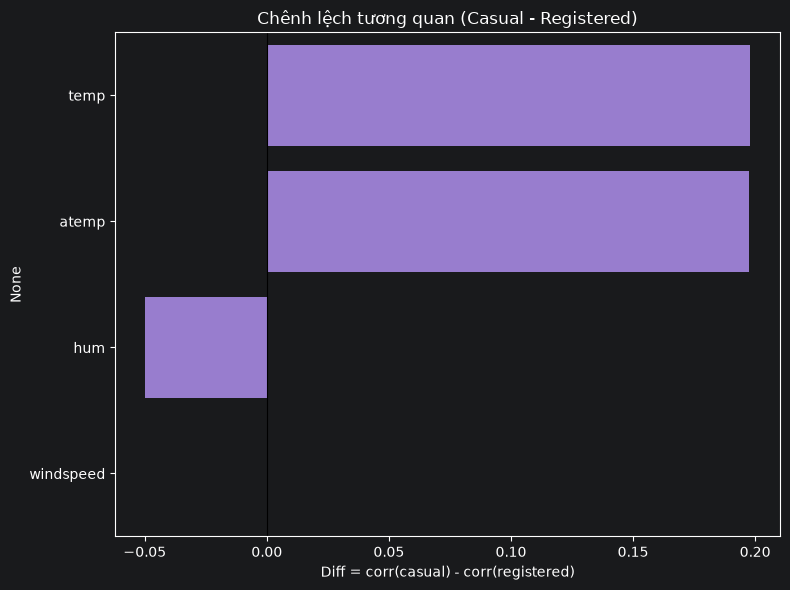

In [390]:

plt.figure(figsize=(8, 6))
sns.barplot(x=compare_corr_sorted['diff'], y=compare_corr_sorted.index, color='mediumpurple')
plt.title('Chênh lệch tương quan (Casual - Registered)')
plt.xlabel('Diff = corr(casual) - corr(registered)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6 Feature Engineer

In [391]:
# ------------------------------------------------------------
# 4. time_period: phân nhóm thời điểm trong ngày
#    0-5h: Night | 6-11h: Morning | 12-16h: Afternoon | 17-21h: Evening | 22-23h: Late Night
# ------------------------------------------------------------
def get_time_period(hr):
    if 0 <= hr <= 5:
        return 'Night'
    elif 6 <= hr <= 11:
        return 'Morning'
    elif 12 <= hr <= 16:
        return 'Afternoon'
    elif 17 <= hr <= 21:
        return 'Evening'
    else:  # 22-23h
        return 'Late Night'

df['time_period'] = df['hr'].apply(get_time_period)
df['time_period'] = df['time_period'].astype("category")


In [392]:
cols = ['season','yr','mnth','hr','holiday','weathersit','workingday','weekday']
df[cols] = df[cols].astype("int")

In [393]:

def feature_selection_anova(df, cat_cols, target_col, alpha=0.05):
    """Lọc các biến Categorical có ảnh hưởng tới Target Continuous bằng One-way ANOVA."""
    anova_results = []

    for col in cat_cols:
        groups = [
            group[target_col].dropna().values
            for _, group in df.groupby(col, observed=True)
        ]

        if len(groups) <= 1:
            continue

        f_stat, p_val = stats.f_oneway(*groups)
        is_selected = p_val < alpha

        # FIX: Append kết quả vào anova_results
        anova_results.append({
            "Feature": col,
            "F-Statistic": round(f_stat, 4),
            "p-value": p_val,
            "Selected": is_selected
        })

    # Nếu không có kết quả nào được tạo
    if not anova_results:
        return [], pd.DataFrame(columns=["Feature", "F-Statistic", "p-value", "Selected"])

    anova_df = pd.DataFrame(anova_results).sort_values(
        by="F-Statistic", ascending=False
    )
    return anova_df.reset_index(drop=True)




In [394]:

from sklearn.ensemble import RandomForestRegressor


def feature_selection_auto(
    df: pd.DataFrame,
    cols:list[str],
    target_col: str,
    must_keep_cols: list[str] = None,
    importance_threshold: float = 0.01,
    dcor_threshold: float = 0.12,
    corr_redundancy_threshold: float = 0.85,
):
    """Phân tích, đánh giá và tự động lọc danh sách Feature tối ưu.

    Parameters:
    - return_df_only: Nếu True thì trả về DataFrame đã lọc. Nếu False thì trả về
    (selected_cols, report_df).
    """
    if must_keep_cols is None:
        must_keep_cols = ["yr"]  # Giữ yr bắt trend cho Tree

    X = df[cols]
    y = df[target_col]

    # 2. Random Forest Importance
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    rf_importances = rf.feature_importances_

    # 3. Tính toán Metrics
    results = []
    y_vals = y.values
    for i, col in enumerate(X.columns):
        x_vals = X[col].values
        pearson_val = np.abs(np.corrcoef(x_vals, y_vals)[0, 1])
        spearman_val = np.abs(X[col].corr(y, method="spearman"))
        dcor_val = dcor.distance_correlation(x_vals, y_vals)

        results.append(
            {
                "Feature": col,
                "Pearson_Abs": round(pearson_val, 4),
                "Spearman_Abs": round(spearman_val, 4),
                "Distance_Corr": round(dcor_val, 4),
                "RF_Importance": round(rf_importances[i], 4),
            }
        )

    res_df = pd.DataFrame(results)

    # 4. Thuật toán tự động Chọn / Loại Feature (Selection Logic)
    # 4a. Xử lý Đa cộng tuyến (Redundancy) - Bỏ 1 trong 2 biến trùng nhau
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop_redundant = set()
    for col in upper_tri.columns:
        high_corr_cols = upper_tri.index[
            upper_tri[col] > corr_redundancy_threshold
        ].tolist()
        for h_col in high_corr_cols:
            if h_col not in must_keep_cols and col not in must_keep_cols:
                # So sánh dcor, bỏ biến yếu hơn
                dcor_h = res_df.loc[
                    res_df["Feature"] == h_col, "Distance_Corr"
                ].values[0]
                dcor_c = res_df.loc[
                    res_df["Feature"] == col, "Distance_Corr"
                ].values[0]
                if dcor_h >= dcor_c:
                    to_drop_redundant.add(col)
                else:
                    to_drop_redundant.add(h_col)

    # 4b. Đánh giá điều kiện Selected
    selected_mask = []
    for _, row in res_df.iterrows():
        f_name = row["Feature"]

        if f_name in must_keep_cols:
            selected_mask.append(True)
        elif f_name in to_drop_redundant:
            selected_mask.append(False)
        else:
            # Điều kiện: Đủ Importance HOẶC đủ Distance Corr
            is_good = (row["RF_Importance"] >= importance_threshold) or (
                row["Distance_Corr"] >= dcor_threshold
            )
            selected_mask.append(is_good)

    res_df["Selected"] = selected_mask
    res_df = res_df.sort_values(
        by=["Selected", "RF_Importance"], ascending=[False, False]
    ).reset_index(drop=True)

    return res_df

In [395]:

from sklearn.ensemble import RandomForestRegressor


def feature_selection_auto(
    df: pd.DataFrame,
    cols:list[str],
    target_col: str,
    must_keep_cols: list[str] = None,
    importance_threshold: float = 0.01,
    dcor_threshold: float = 0.12,
    corr_redundancy_threshold: float = 0.85,
):
    """Phân tích, đánh giá và tự động lọc danh sách Feature tối ưu.

    Parameters:
    - return_df_only: Nếu True thì trả về DataFrame đã lọc. Nếu False thì trả về
    (selected_cols, report_df).
    """
    if must_keep_cols is None:
        must_keep_cols = ["yr"]  # Giữ yr bắt trend cho Tree

    X = df[cols]
    y = df[target_col]

    # 2. Random Forest Importance
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    rf_importances = rf.feature_importances_

    # 3. Tính toán Metrics
    results = []
    y_vals = y.values
    for i, col in enumerate(X.columns):
        x_vals = X[col].values
        pearson_val = np.abs(np.corrcoef(x_vals, y_vals)[0, 1])
        spearman_val = np.abs(X[col].corr(y, method="spearman"))
        dcor_val = dcor.distance_correlation(x_vals, y_vals)

        results.append(
            {
                "Feature": col,
                "Pearson_Abs": round(pearson_val, 4),
                "Spearman_Abs": round(spearman_val, 4),
                "Distance_Corr": round(dcor_val, 4),
                "RF_Importance": round(rf_importances[i], 4),
            }
        )

    res_df = pd.DataFrame(results)

    # 4. Thuật toán tự động Chọn / Loại Feature (Selection Logic)
    # 4a. Xử lý Đa cộng tuyến (Redundancy) - Bỏ 1 trong 2 biến trùng nhau
    corr_matrix = X.corr().abs()
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop_redundant = set()
    for col in upper_tri.columns:
        high_corr_cols = upper_tri.index[
            upper_tri[col] > corr_redundancy_threshold
        ].tolist()
        for h_col in high_corr_cols:
            if h_col not in must_keep_cols and col not in must_keep_cols:
                # So sánh dcor, bỏ biến yếu hơn
                dcor_h = res_df.loc[
                    res_df["Feature"] == h_col, "Distance_Corr"
                ].values[0]
                dcor_c = res_df.loc[
                    res_df["Feature"] == col, "Distance_Corr"
                ].values[0]
                if dcor_h >= dcor_c:
                    to_drop_redundant.add(col)
                else:
                    to_drop_redundant.add(h_col)

    # 4b. Đánh giá điều kiện Selected
    selected_mask = []
    for _, row in res_df.iterrows():
        f_name = row["Feature"]

        if f_name in must_keep_cols:
            selected_mask.append(True)
        elif f_name in to_drop_redundant:
            selected_mask.append(False)
        else:
            # Điều kiện: Đủ Importance HOẶC đủ Distance Corr
            is_good = (row["RF_Importance"] >= importance_threshold) or (
                row["Distance_Corr"] >= dcor_threshold
            )
            selected_mask.append(is_good)

    res_df["Selected"] = selected_mask
    res_df = res_df.sort_values(
        by=["Selected", "RF_Importance"], ascending=[False, False]
    ).reset_index(drop=True)

    return res_df

## 7. Train Model

In [396]:

split_idx = int(len(df) * 0.8)

In [397]:
df.drop(columns=["instant",'season_name','weathersit_name','windspeed_actual','hum_actual','temp_actual','holiday_name','workingday_name','month_name','weekday_name'], inplace=True)

In [398]:
casual_df =df.copy()

In [399]:
registered_df =df.copy()

In [400]:

casual_df['workingday_rush'] = (
    (casual_df['workingday'] == 1) &
    (casual_df['hr'].isin([16, 17, 18]))
).astype(int)

casual_df['not_workingday_rush'] = (
    (casual_df['workingday'] == 0) &
    (casual_df['hr'].isin([13,14,15]))
).astype(int)

registered_df['workingday_rush'] = (
    (registered_df['workingday'] == 1) &
    (registered_df['hr'].isin([8,17,18]))
).astype(int)

registered_df['not_workingday_rush'] = (
    (registered_df['workingday'] == 0) &
    (registered_df['hr'].isin([12,13,14]))
).astype(int)

In [401]:
registered_df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'time_period', 'workingday_rush',
       'not_workingday_rush'],
      dtype='str')

In [402]:
num_cols = registered_df.select_dtypes(include="number").drop(columns=["casual","registered","cnt"]).columns.tolist()
cat_cols = registered_df.select_dtypes(include="category").columns.tolist()

In [403]:
anova_casual_df = feature_selection_anova(casual_df,cat_cols,'casual')
print("="*30 + " Casual " + "="*30)
print("")
print(anova_casual_df)
print("")

anova_registered_df = feature_selection_anova(registered_df,cat_cols,'registered')
print("="*30 + " Registered " + "="*30)
print("")
print(anova_registered_df)
print("")

============================== Casual ==============================

       Feature  F-Statistic  p-value  Selected
0  time_period     1447.046      0.0      True

============================== Registered ==============================

       Feature  F-Statistic  p-value  Selected
0  time_period    2308.6704      0.0      True



In [404]:
mi_casual_df = feature_selection_auto(casual_df,num_cols,'casual')
mi_casual_df

C:\UIT\Lab\Data Analysic\Project\.venv\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(int64, 1d, C), readonly array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
C:\UIT\Lab\Data Analysic\Project\.venv\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(float64, 1d, C), readonly array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


,Feature,Pearson_Abs,Spearman_Abs,Distance_Corr,RF_Importance,Selected
0,hr,0.3012,0.4767,0.4599,0.3465,True
1,workingday,0.3009,0.1767,0.2772,0.1815,True
2,atemp,0.4541,0.5704,0.5153,0.1081,True
3,hum,0.3470,0.3882,0.3666,0.0557,True
4,yr,0.1428,0.1147,0.1372,0.0409,True
5,mnth,0.0685,0.1181,0.2034,0.0249,True
6,not_workingday_rush,0.4209,0.2563,0.3713,0.0245,True
7,windspeed,0.0903,0.1229,0.1149,0.0208,True
8,weekday,0.0327,0.0127,0.1327,0.0190,True
9,season,0.1202,0.1837,0.2204,0.0084,True


In [405]:
selected_num_casuals = ["atemp",'hum','windspeed',"workingday","yr","not_workingday_rush","workingday_rush"]
selected_cat_casuals = ["time_period","hr","mnth","weathersit","season","weekday"]

In [406]:
mi_registered_df = feature_selection_auto(registered_df,num_cols,'registered')
mi_registered_df

C:\UIT\Lab\Data Analysic\Project\.venv\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(int64, 1d, C), readonly array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
C:\UIT\Lab\Data Analysic\Project\.venv\Lib\site-packages\dcor\_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) readonly array(float64, 1d, C), readonly array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


,Feature,Pearson_Abs,Spearman_Abs,Distance_Corr,RF_Importance,Selected
0,workingday_rush,0.6101,0.4148,0.5462,0.3707,True
1,hr,0.3741,0.5106,0.5095,0.2719,True
2,yr,0.2537,0.2210,0.2470,0.1045,True
3,workingday,0.1343,0.0831,0.1249,0.0375,True
4,season,0.1742,0.1824,0.1928,0.0355,True
5,mnth,0.1223,0.1271,0.1596,0.0349,True
6,atemp,0.3326,0.3730,0.3454,0.0243,True
7,weathersit,0.1210,0.1121,0.1178,0.0218,True
8,hum,0.2739,0.3385,0.3034,0.0216,True
9,weekday,0.0216,0.0347,0.0632,0.0142,True


In [407]:
selected_num_registered = ["atemp",'hum',"workingday","yr","not_workingday_rush","workingday_rush"]
selected_cat_registered = ["time_period","hr","mnth","weathersit","season","weekday"]

In [408]:
X_train_casual,X_test_casual = (casual_df[selected_cat_casuals+selected_num_casuals].iloc[:split_idx],casual_df[selected_cat_casuals+selected_num_casuals].iloc[split_idx:])

y_train_casual,y_test_casual = (casual_df['casual'].iloc[:split_idx],casual_df['casual'].iloc[split_idx:])

In [409]:
X_train_registered,X_test_registered = (registered_df[selected_cat_registered + selected_num_registered].iloc[:split_idx],
                      registered_df[selected_cat_registered + selected_num_registered].iloc[split_idx:])

y_train_registered,y_test_registered = (casual_df['registered'].iloc[:split_idx],casual_df['registered'].iloc[split_idx:])

In [410]:
from sklearn.base import BaseEstimator, TransformerMixin
class CyclicalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, max_val):
        self.max_val = max_val

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X)
        sin_trans = np.sin(2 * np.pi * X / self.max_val)
        cos_trans = np.cos(2 * np.pi * X / self.max_val)
        return np.hstack([sin_trans, cos_trans])


In [411]:

# 1. Khai báo danh sách cột chuẩn
NUM_COLS = ["atemp", "hum", "windspeed"]
BIN_COLS = ["yr", "workingday", "workingday_rush", "not_workingday_rush"]
CAT_INT_COLS = ["season", "weathersit", "weekday"] # Đã tách hr, mnth ra làm Cyclical
CAT_STR_COLS = ["time_period"]

# 3. Hàm Preprocessor chuẩn chỉnh
def build_preprocessors(selected_num, selected_cat):
    # Lọc danh sách cột
    num_cols = [c for c in selected_num if c in NUM_COLS]
    bin_cols = [c for c in selected_num if c in BIN_COLS]

    cat_int_cols = [c for c in selected_cat if c in CAT_INT_COLS]
    cat_str_cols = [c for c in selected_cat if c in CAT_STR_COLS]

    all_cat_cols = cat_int_cols + cat_str_cols

    # Check sự tồn tại của biến chu kỳ
    has_hr = "hr" in selected_cat
    has_mnth = "mnth" in selected_cat

    # --- LINEAR MODELS (Ridge / Lasso) ---
    transformers_line = []

    if num_cols:
        num_pipeline = Pipeline([
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scaler", StandardScaler())
        ])
        transformers_line.append(("num", num_pipeline, num_cols))

    if bin_cols:
        transformers_line.append(("bin", StandardScaler(with_mean=False), bin_cols))

    if all_cat_cols:
        # Cả cat_str lẫn cat_int đều phải OHE cho Linear
        transformers_line.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), all_cat_cols))

    if has_hr:
        transformers_line.append(("hr_cyclical", CyclicalEncoder(max_val=24), ["hr"]))

    if has_mnth:
        transformers_line.append(("mnth_cyclical", CyclicalEncoder(max_val=12), ["mnth"]))

    prep_line = ColumnTransformer(transformers=transformers_line)

    # --- TREE-BASED MODELS (XGBoost, LightGBM, RF) ---
    # Tree ăn trực tiếp Numeric + Binary + Cyclical (hr, mnth) ở dạng gốc
    tree_passthrough_cols = num_cols + bin_cols
    if has_hr: tree_passthrough_cols.append("hr")
    if has_mnth: tree_passthrough_cols.append("mnth")
    if cat_int_cols: tree_passthrough_cols.extend(cat_int_cols) # Các số int 1,2,3,4 passthrough thẳng

    transformers_tree = [
        ("passthrough_features", "passthrough", tree_passthrough_cols)
    ]

    # Chỉ encode những biến thực sự dạng Chữ (String) cho Tree
    if cat_str_cols:
        transformers_tree.append((
            "cat_str",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_str_cols
        ))

    prep_tree = ColumnTransformer(transformers=transformers_tree)

    return prep_line, prep_tree

In [412]:

from sklearn.compose import TransformedTargetRegressor

def get_param_grids(prep_line, prep_tree):
    """
    Trả về Dict PARAM_GRIDS hoàn chỉnh tích hợp TransformedTargetRegressor (Log1p)
    Tránh Mutated State giữa các lần Search.
    """

    # 1. Base Pipelines
    pipe_ridge = Pipeline([
        ("prep", prep_line),
        ("ridge", Ridge())
    ])

    pipe_tree = Pipeline([
        ("prep", prep_tree),
        ("tree", DecisionTreeRegressor(random_state=42))
    ])

    pipe_rf = Pipeline([
        ("prep", prep_tree),
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    # 2. Return Dict với TransformedTargetRegressor Wrapper
    return {
        "PolyLinear (Baseline)": {
            "model": TransformedTargetRegressor(
                regressor=pipe_ridge,
                func=np.log1p,
                inverse_func=np.expm1
            ),
            "params": {
                "regressor__prep__num__poly__degree": [1, 2],
                "regressor__ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
            }
        },

        "Decision Tree": {
            "model": TransformedTargetRegressor(
                regressor=pipe_tree,
                func=np.log1p,
                inverse_func=np.expm1
            ),
            "params": {
                "regressor__tree__max_depth": [3, 5, 8, 12, 20],
                "regressor__tree__min_samples_leaf": [1, 5, 10, 20],
                "regressor__tree__max_features": ["sqrt", 0.5, 1.0],
            }
        },

        "Random Forest": {
            "model": TransformedTargetRegressor(
                regressor=pipe_rf,
                func=np.log1p,
                inverse_func=np.expm1
            ),
            "params": {
                "regressor__rf__n_estimators": [100, 300],
                "regressor__rf__max_depth": [5, 10, 20], # Bỏ depth=1 vì quá nông cho RF
                "regressor__rf__max_features": [0.3, 0.5, "sqrt"],
                "regressor__rf__min_samples_leaf": [1, 5, 10],
            }
        }
    }

In [413]:
from sklearn.model_selection import TimeSeriesSplit
def train_models(X, y, param_grids, n_splits=5, verbose=True):
    results = []

    tscv = TimeSeriesSplit(n_splits=n_splits)
    for model_name, config in param_grids.items():

        if verbose:
            print("\n" + "=" * 60)
            print(f"  Tuning: {model_name}")
            print("=" * 60)

        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )

        grid_search.fit(X, y)

        result = {
            "model_name": model_name,
            "best_estimator": grid_search.best_estimator_,
            "best_params": grid_search.best_params_,
            "mae_mean": -grid_search.best_score_
        }

        results.append(result)

        if verbose:
            print(f"  Best params: {result['best_params']}")
            print(f"  CV MAE     : {result['mae_mean']:.4f}")

    return results

In [414]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

def evaluate_ts_model(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    scoring = {
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }

    # n_jobs=-1 để tận dụng tối đa CPU
    cv_results = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)

    return {
        "mae_mean": -np.mean(cv_results['test_mae']),
        "mae_std": np.std(cv_results['test_mae']),
        "rmse_mean": -np.mean(cv_results['test_rmse']),
        "rmse_std": np.std(cv_results['test_rmse']),
        "r2_mean": np.mean(cv_results['test_r2']),
        "r2_std": np.std(cv_results['test_r2'])
    }

In [415]:
def get_best_model(results, sort_by="mae_mean", ascending=True):
    sorted_results = sorted(
        results,
        key=lambda x: x[sort_by],
        reverse=not ascending
    )

    sorted_df = pd.DataFrame(results).drop(
        columns=["best_params",'best_estimator']
    )

    print_evaluate_model(sorted_df)

    best = sorted_results[0]

    print(f"\n============================================================")
    print(f"✅ Model tốt nhất : {best['model_name']}")
    print(f"   MAE  = {best['mae_mean']:.4f} ± {best['mae_std']:.4f}")
    print(f"   RMSE = {best['rmse_mean']:.4f}")
    print(f"   R²   = {best['r2_mean']:.4f}")
    print(f"   Params: {best['best_params']}")
    print(f"============================================================")

    return best['best_estimator'],sorted_df


In [416]:
def print_evaluate_model(sorted_df):
    display_cols = [
        "Model",
        "MAE (mean)",
        "MAE (std)",
        "RMSE (mean)",
        "RMSE (std)",
        "R² (mean)",
        "R2 (std)",
    ]

    print(f"\n{'='*60}")
    print("  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)")
    print(f"{'='*60}")

    sorted_df.columns = display_cols

    print(sorted_df[display_cols].to_string(index=False))

In [417]:
def get_result_evaluate(num_cols,cat_cols,X,y):
    prep_line,prep_tree = build_preprocessors(num_cols,cat_cols)
    param_grids = get_param_grids(prep_line,prep_tree)
    results = train_models(
        X,
        y,
        param_grids
    )

    for result in results:
        metrics = evaluate_ts_model(
            result["best_estimator"],
            X,
            y
        )
        result.update(metrics)

    best,sorted_df = get_best_model(results)
    return best,sorted_df

best_casual,result_casual = get_result_evaluate(selected_num_casuals,selected_cat_casuals,X_train_casual,y_train_casual)
best_registered,result_registered = get_result_evaluate(selected_num_registered,selected_cat_registered,X_train_registered,y_train_registered)


  Tuning: PolyLinear (Baseline)
  Best params: {'regressor__prep__num__poly__degree': 2, 'regressor__ridge__alpha': 0.01}
  CV MAE     : 16.9337

  Tuning: Decision Tree
  Best params: {'regressor__tree__max_depth': 20, 'regressor__tree__max_features': 1.0, 'regressor__tree__min_samples_leaf': 20}
  CV MAE     : 15.6165

  Tuning: Random Forest
  Best params: {'regressor__rf__max_depth': 20, 'regressor__rf__max_features': 0.5, 'regressor__rf__min_samples_leaf': 1, 'regressor__rf__n_estimators': 300}
  CV MAE     : 13.8041

  KẾT QUẢ TỔNG HỢP (sort theo MAE tăng dần)
                Model  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  R² (mean)  R2 (std)
PolyLinear (Baseline)   16.933666   4.580867    30.672263    8.031241   0.531815  0.174281
        Decision Tree   15.616531   3.914853    27.406743    6.636927   0.623732  0.110118
        Random Forest   13.804116   3.431392    24.722310    7.207087   0.702549  0.086520

✅ Model tốt nhất : Random Forest
   MAE  = 13.8041 ± 3.4314
 

In [418]:
def plot_result_evaluates(results):

    # Giả sử df là results_df trả về từ evaluate_models
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(
        data=results, x="MAE (mean)", y="Model", palette="Blues_r",hue="Model"
    )

    plt.title("So sánh MAE (CV Mean) giữa các Models - Thấp hơn là tốt hơn")
    plt.xlabel("Mean Absolute Error (MAE)")
    plt.ylabel("Model")

    # Hiển thị con số cụ thể trên đầu mỗi cột
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f"{width:.4f}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(5, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()



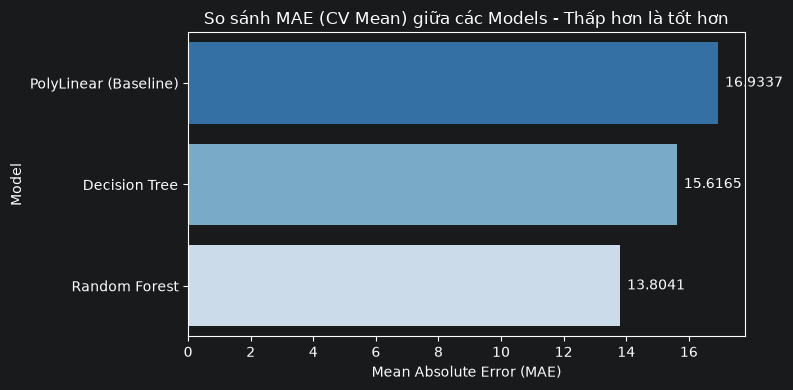

In [419]:
plot_result_evaluates(results=result_casual)

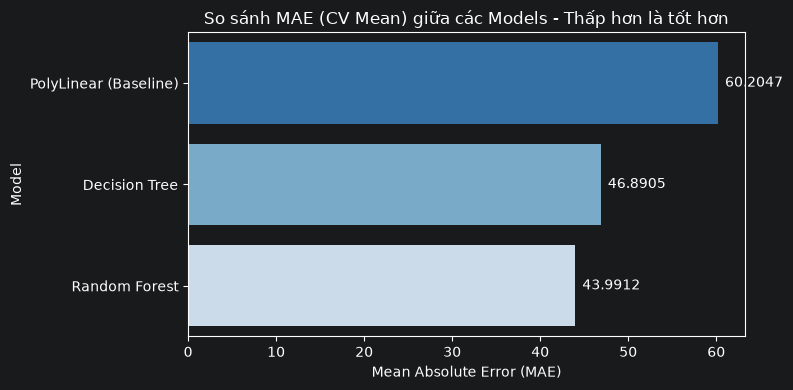

In [420]:
plot_result_evaluates(results=result_registered)

## 8. Đánh giá model

In [421]:
y_predict_casual = best_casual.predict(X_test_casual)

In [422]:
y_predict_registered = best_registered.predict(X_test_registered)

In [423]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

def evaluate_model(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mask = y_true != 0
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    mape  = mean_absolute_percentage_error(
        y_true[mask],
        y_pred[mask]
    ) * 100
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred,0,None))))

    df_result = pd.DataFrame({
        'Metric':      ['R²', 'RMSE', 'RMSLE', 'MAPE (%)'],
        'Score':       [round(r2,4), round(rmse,2), round(rmsle,4), round(mape,2)],
        'Diễn giải':  [
            'Tỷ lệ phương sai giải thích được (càng gần 1 càng tốt)',
            'Căn bậc hai của sai số bình phương trung bình (cùng đơn vị target)',
            'RMSE trên log-scale, ít nhạy cảm với outlier',
            'Sai số phần trăm tuyệt đối trung bình (dễ hiểu)',
        ]
    })
    return df_result


In [424]:
evaluate_model(y_test_casual,y_predict_casual)

,Metric,Score,Diễn giải
0,R²,0.8328,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,22.9000,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.5325,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),43.9900,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


In [425]:
evaluate_model(y_test_registered,y_predict_registered)

,Metric,Score,Diễn giải
0,R²,0.8735,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,66.9500,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.4020,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),33.6800,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


In [426]:
def plot_evaluate_sorted(y_test, y_pred):
    y_test = np.array(y_test).flatten()
    y_pred = np.array(y_pred).flatten()

    idx = np.argsort(y_test)
    y_test_s = y_test[idx]
    y_pred_s = y_pred[idx]
    x = np.arange(len(y_test_s))
    residuals = y_test_s - y_pred_s

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Plot 1: Actual vs Predicted
    ax1 = axes[0]
    ax1.scatter(x, y_pred_s, color='#2a78d6', s=10, alpha=0.5, label='Predicted', zorder=2)
    ax1.plot(x, y_test_s, color='#eb6834', linewidth=2, label='Actual', zorder=3)
    ax1.set_title('Actual vs Predicted (sorted by actual)', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Residual
    ax2 = axes[1]
    ax2.scatter(x, residuals, color='#2a78d6', s=10, alpha=0.4, zorder=2)
    ax2.axhline(0, color='#e34948', linewidth=2, linestyle='--', label='Zero error')
    ax2.fill_between(x, residuals, 0, where=(residuals > 0),
                     alpha=0.1, color='#eb6834', label='Under-predict')
    ax2.fill_between(x, residuals, 0, where=(residuals < 0),
                     alpha=0.1, color='#2a78d6', label='Over-predict')
    ax2.set_title('Residuals (Actual - Predicted)', fontsize=13)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Residual Distribution Plot
    sns.histplot(
        residuals, kde=True, ax=axes[2], color="#ff7f0e", bins=20, stat="density"
    )
    axes[2].axvline(
        x=0, color="r", linestyle="--", lw=2, label="Zero Error Line"
    )
    axes[2].set_title("Residual Distribution")
    axes[2].set_xlabel("Residual Value")
    axes[2].set_ylabel("Density")
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    plt.tight_layout()
    plt.show()

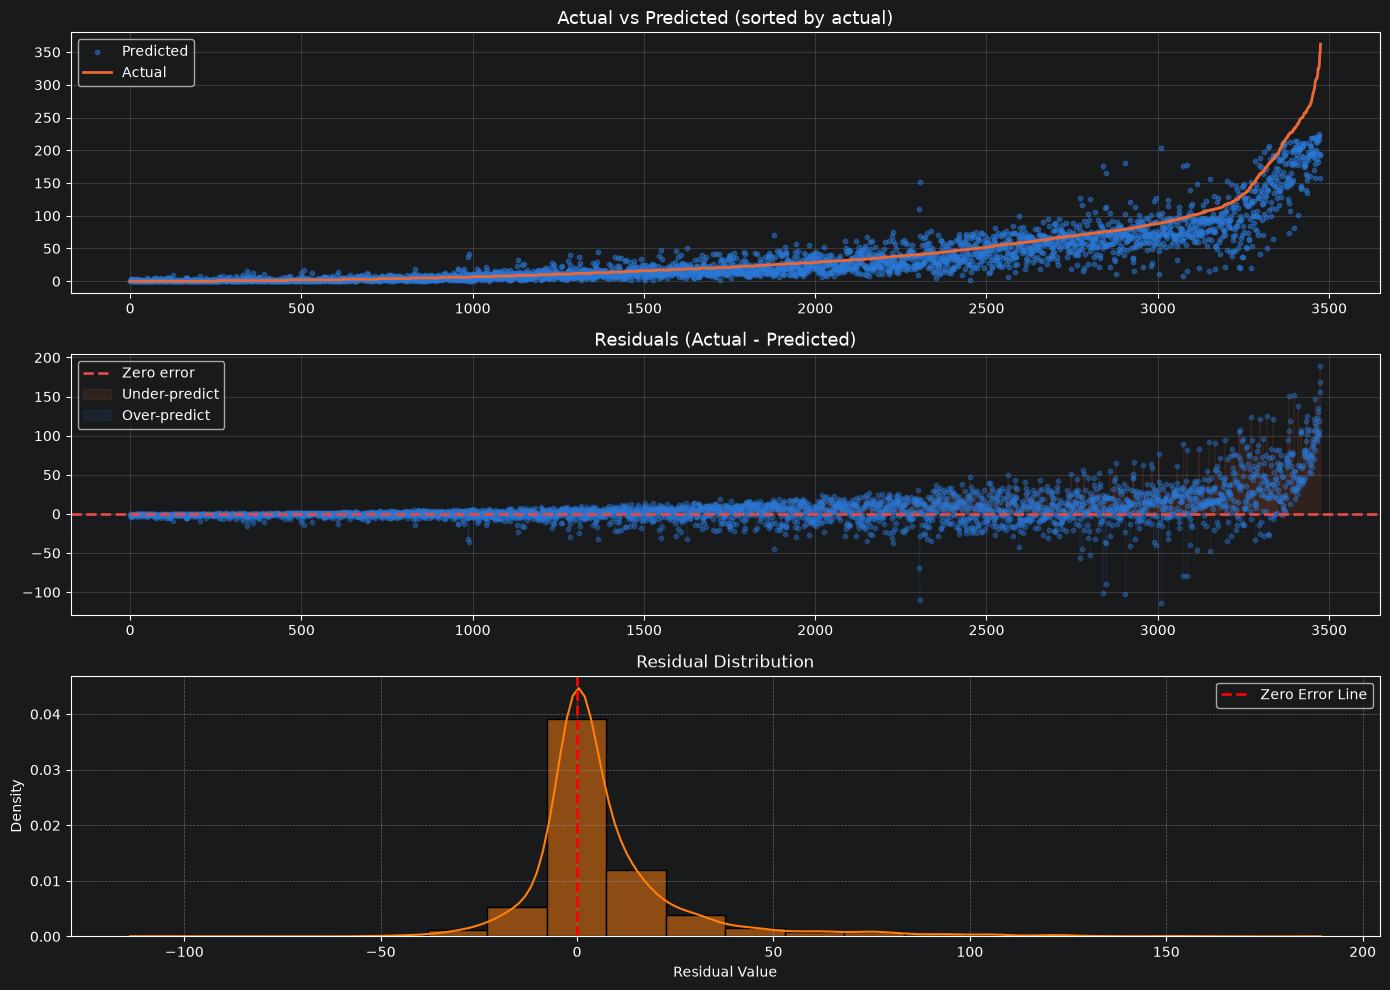

<Figure size 640x480 with 0 Axes>

In [427]:
plot_evaluate_sorted(y_test_casual, y_predict_casual)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21684\3169878529.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


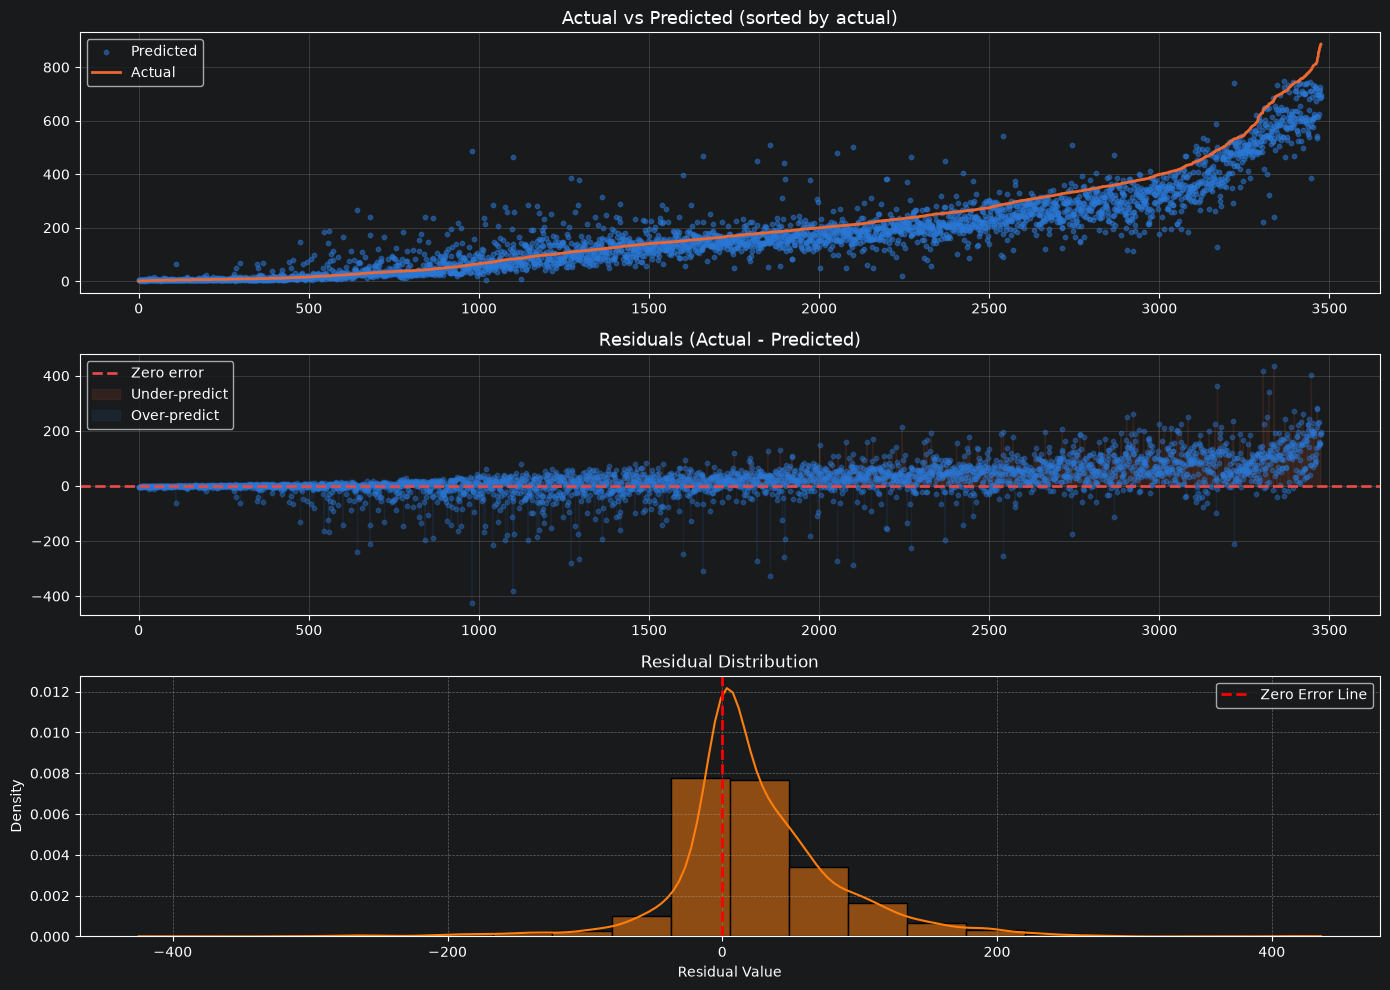

<Figure size 640x480 with 0 Axes>

In [428]:
plot_evaluate_sorted(y_test_registered, y_predict_registered)

In [429]:
def plot_residual_diagnostics(y_true, y_pred, model_name="Model"):
    """
    Mô tả hành vi residual của model (không phải kiểm định giả định thống kê,
    vì áp dụng cho non-parametric model như Random Forest/Decision Tree).
    Dùng để phát hiện: model có thiên vị theo vùng giá trị nào không (bias),
    có heteroscedasticity thực tế không (dù RF không giả định homoscedastic),
    residual có pattern hệ thống nào còn sót lại không.
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Residual Diagnostics — {model_name} (mô tả, không phải kiểm định giả định)',
                 fontsize=14, fontweight='bold')

    axes[0,0].scatter(y_pred, residuals, alpha=0.3, s=10, color='#2a78d6')
    axes[0,0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0,0].set_title('Residual vs Predicted\n(phát hiện bias theo vùng giá trị)', fontsize=11)

    stats.probplot(residuals, dist='norm', plot=axes[0,1])
    axes[0,1].set_title('Q-Q Plot (chỉ mang tính mô tả)', fontsize=11)

    sns.histplot(residuals, kde=True, ax=axes[1,0], color='#eb6834', bins=40, stat='density')
    axes[1,0].axvline(0, color='red', linestyle='--')
    axes[1,0].set_title('Phân phối Residual', fontsize=11)

    axes[1,1].scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.3, s=10, color='#1baf7a')
    axes[1,1].set_title('Scale-Location', fontsize=11)

    plt.tight_layout()
    plt.show()

    # Bỏ Durbin-Watson & Shapiro-Wilk, hoặc giữ nhưng đổi cách in ra để không
    # gợi ý đây là "kiểm định giả định model"
    print(f'\n── Thống kê mô tả residual ({model_name}) ──')
    print(f'Mean residual : {residuals.mean():.4f}  (gần 0 là tốt, cho biết model có bias hệ thống hay không)')
    print(f'Std residual  : {residuals.std():.4f}')

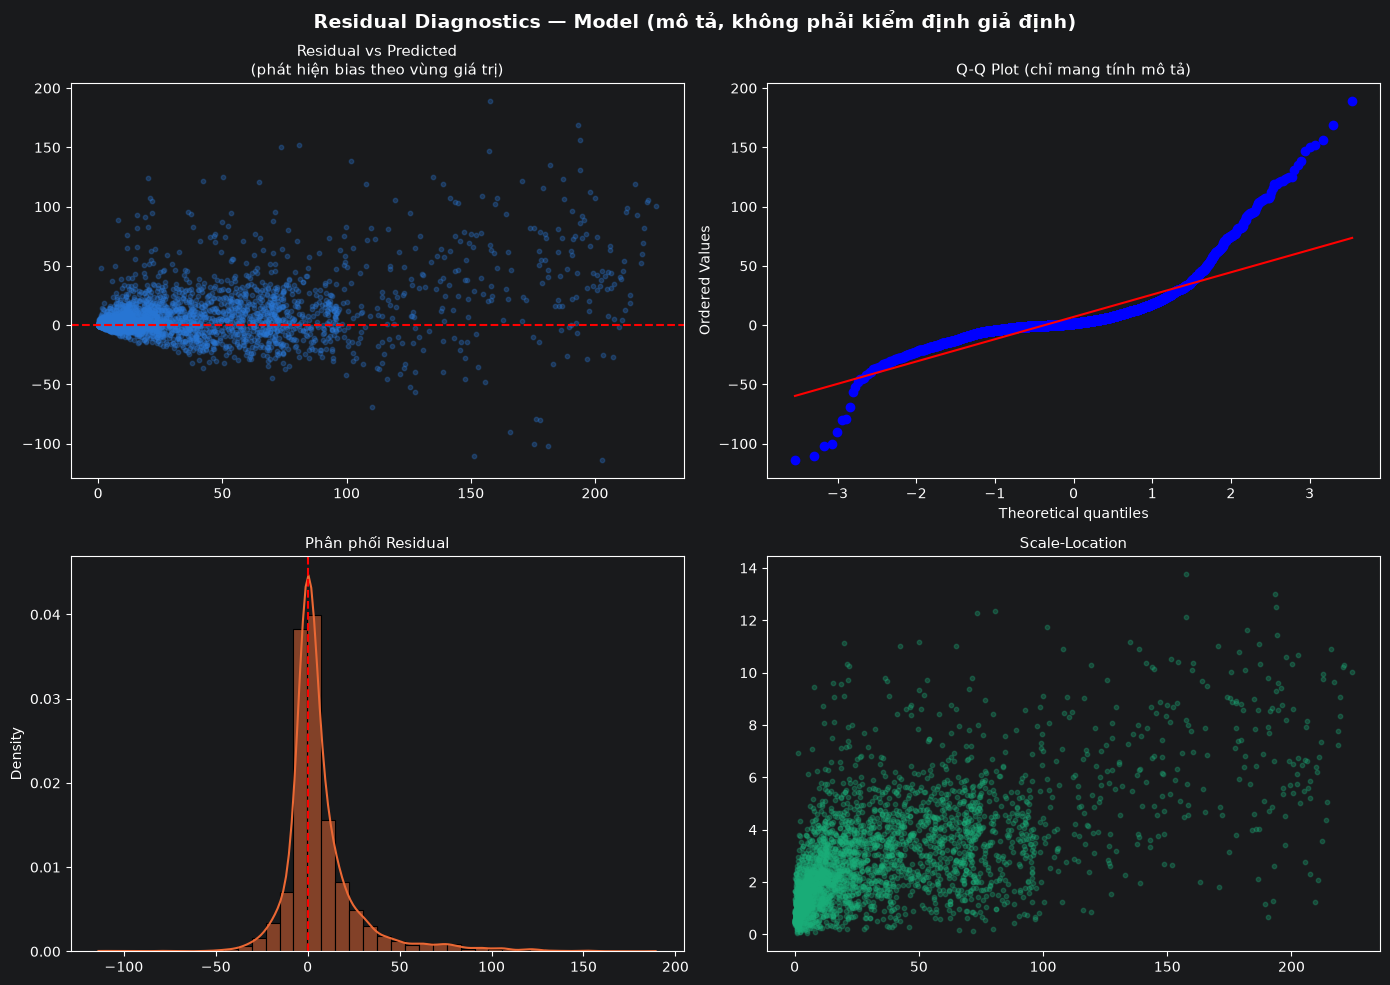


── Thống kê mô tả residual (Model) ──
Mean residual : 6.9261  (gần 0 là tốt, cho biết model có bias hệ thống hay không)
Std residual  : 21.8279


In [430]:
plot_residual_diagnostics(y_test_casual,y_predict_casual)


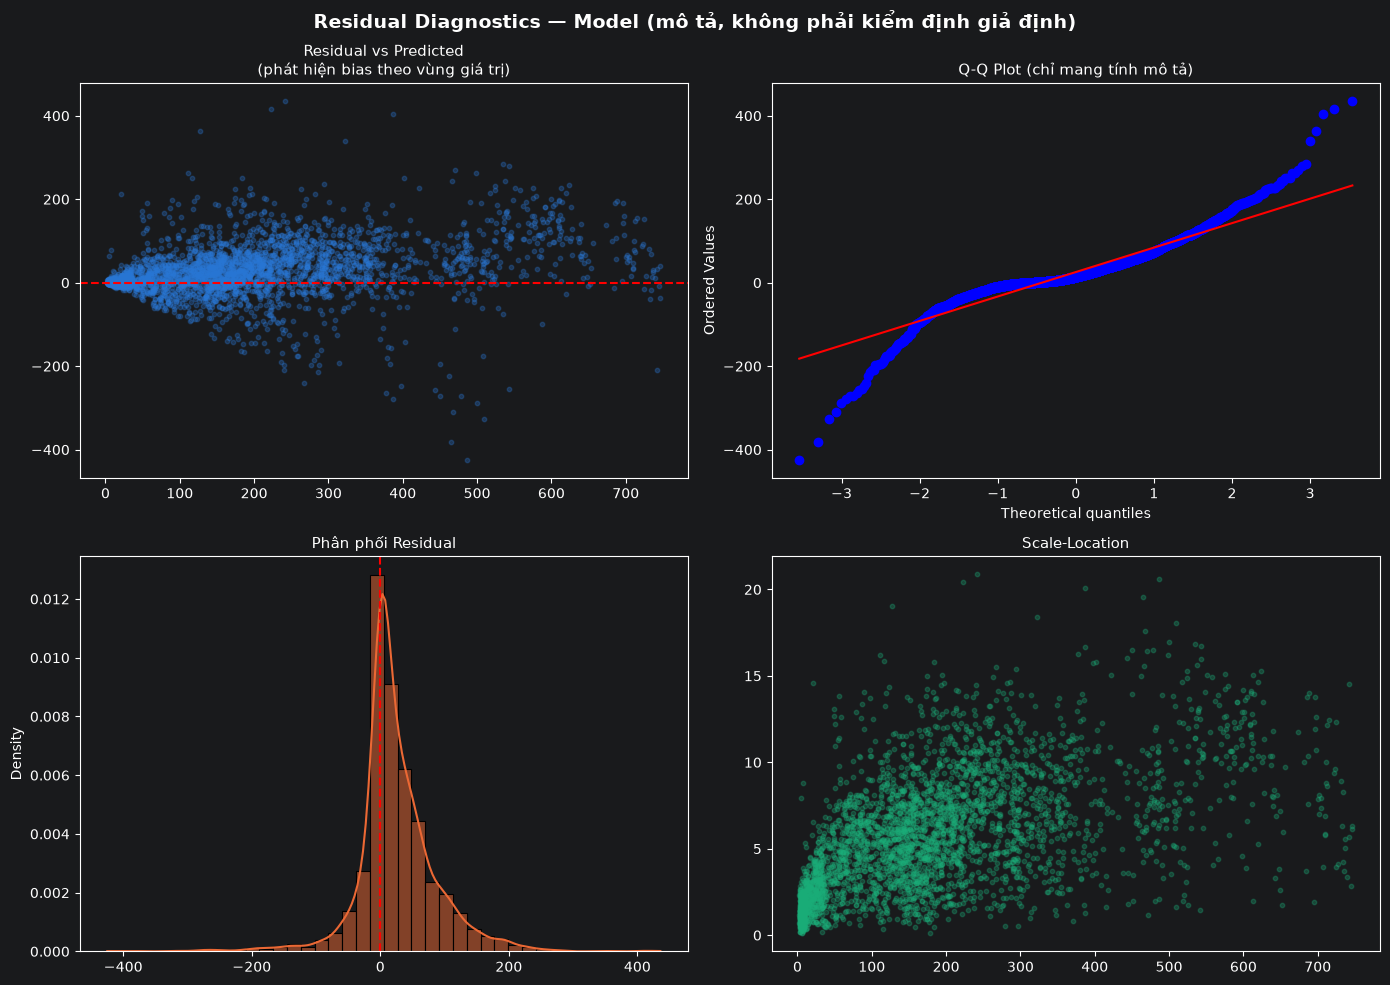


── Thống kê mô tả residual (Model) ──
Mean residual : 25.4792  (gần 0 là tốt, cho biết model có bias hệ thống hay không)
Std residual  : 61.9117


In [431]:
plot_residual_diagnostics(y_test_registered,y_predict_registered)

In [432]:
y_predict = y_predict_casual + y_predict_registered
y_test = y_test_registered + y_test_casual

In [433]:
evaluate_model(y_test,y_predict)

,Metric,Score,Diễn giải
0,R²,0.8732,Tỷ lệ phương sai giải thích được (càng gần 1 c...
1,RMSE,78.5100,Căn bậc hai của sai số bình phương trung bình ...
2,RMSLE,0.3907,"RMSE trên log-scale, ít nhạy cảm với outlier"
3,MAPE (%),31.6900,Sai số phần trăm tuyệt đối trung bình (dễ hiểu)


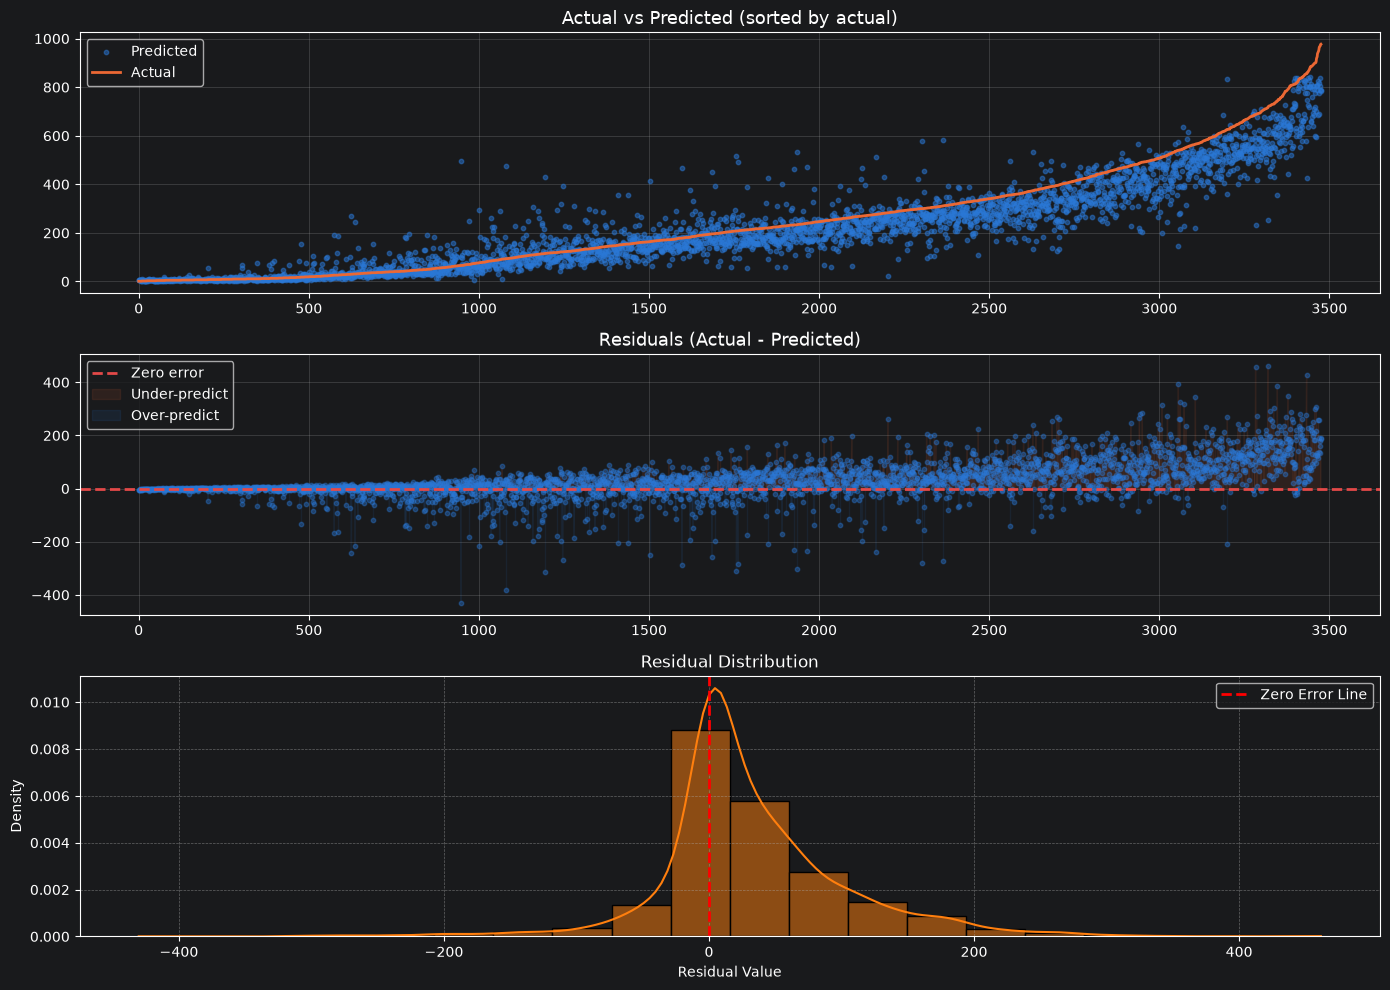

<Figure size 640x480 with 0 Axes>

In [434]:
plot_evaluate_sorted(y_test,y_predict)

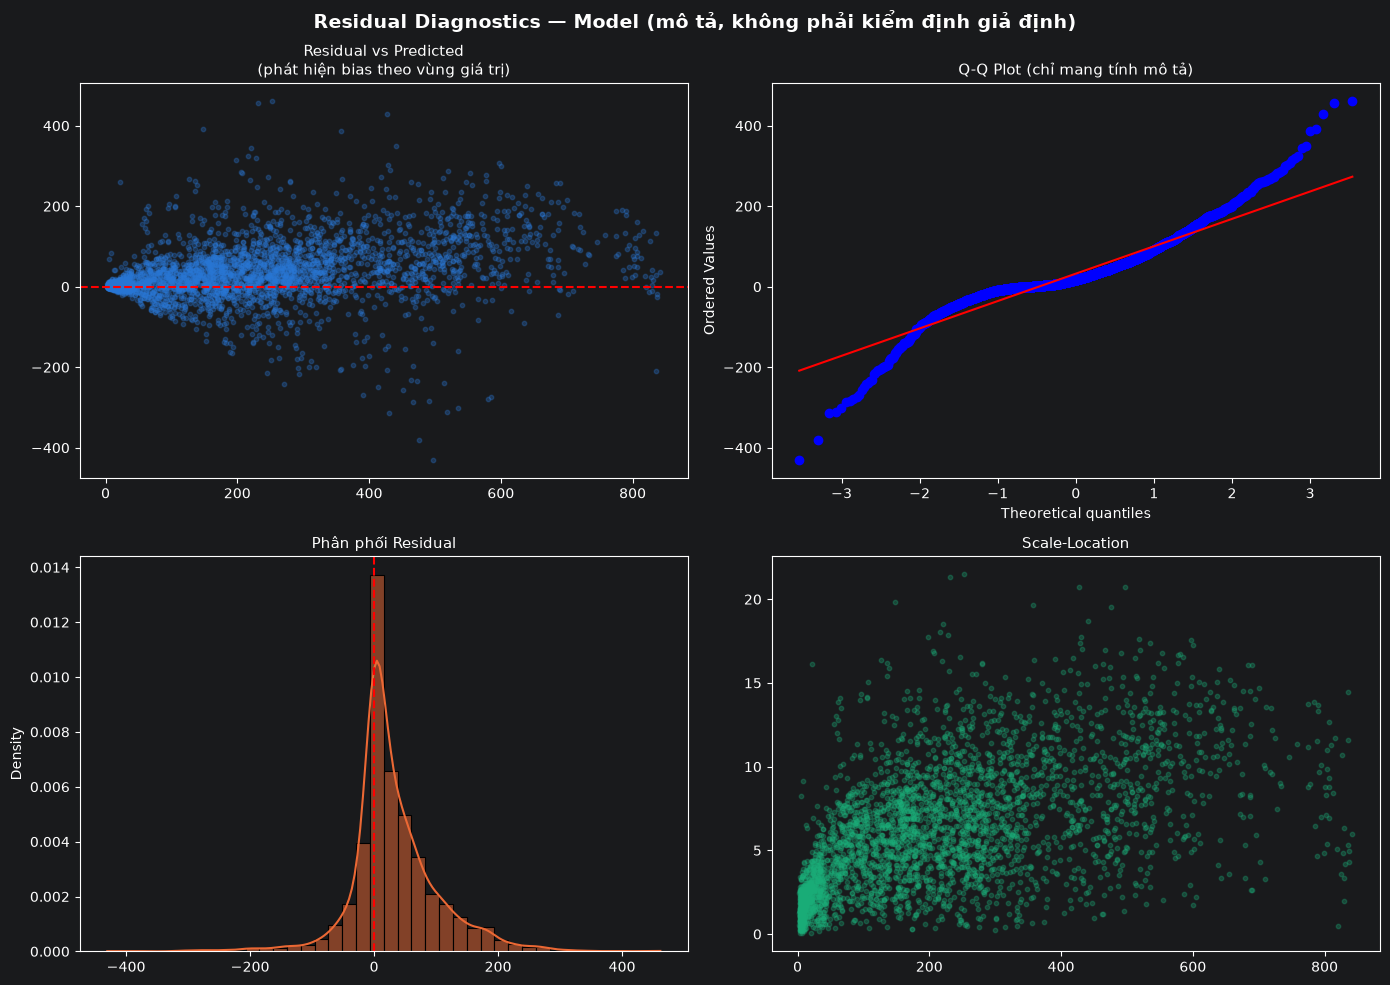


── Thống kê mô tả residual (Model) ──
Mean residual : 32.4053  (gần 0 là tốt, cho biết model có bias hệ thống hay không)
Std residual  : 71.5072


In [435]:
plot_residual_diagnostics(y_test,y_predict)